In [1]:
import subprocess, sys, torch

print(f"torch {torch.__version__}  cuda {torch.version.cuda}  python {sys.version.split()[0]}")

_TV = torch.__version__.split('+')[0]
_CU = "cu" + torch.version.cuda.replace('.', '')[:3]

def _pip(cmd, tag=""):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    ok = r.returncode == 0
    print(f"  {'[ok]' if ok else '[FAIL]'} {tag or cmd.split()[2]}")
    if not ok:
        for ln in (r.stderr or r.stdout).strip().split('\n')[-3:]:
            if ln.strip():
                print(f"       {ln.strip()}")

print("\ninstalling pyg...")
_pip(f"pip install torch-geometric -q", "torch-geometric")
_pip(f"pip install torch-scatter torch-sparse "
     f"-f https://data.pyg.org/whl/torch-{_TV}+{_CU}.html -q",
     "scatter/sparse")

print("materials libs...")
_pip("pip install pymatgen -q", "pymatgen")
_pip("pip install mp-api -q", "mp-api")

print("ml utils...")
_pip("pip install scikit-learn matplotlib seaborn tqdm -q", "sklearn+plotting")

print("\nverifying imports...")
for name, stmt in [
    ("torch_geometric", "import torch_geometric"),
    ("pymatgen",        "from pymatgen.core import Structure"),
    ("sklearn",         "from sklearn.linear_model import Ridge"),
]:
    try:
        exec(stmt); print(f"  {name}")
    except Exception as e:
        print(f"  {name} FAILED: {e}")

print("done")

torch 2.10.0+cu128  cuda 12.8  python 3.12.12

installing pyg...
  [ok] torch-geometric
  [ok] scatter/sparse
materials libs...
  [ok] pymatgen
  [ok] mp-api
ml utils...
  [ok] sklearn+plotting

verifying imports...
  torch_geometric
  pymatgen
  sklearn
done


In [2]:
import os, json, time, warnings, pickle, math, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm import tqdm
from collections import defaultdict
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, OneCycleLR
from torch.cuda.amp import autocast, GradScaler  # deprecated but works fine

from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing, global_mean_pool, global_add_pool

from pymatgen.core import Structure
from pymatgen.core.periodic_table import Element

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.manifold import TSNE

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
})
COLORS = ['#2C7BB6', '#D7191C', '#1A9641', '#FDAE61', '#762A83']

cfg = dict(
    cutoff      = 6.0,       
    max_nbrs    = 12,        
    n_rbf       = 32,        

    node_dim    = 128,
    edge_dim    = 64,
    n_mp_layers = 4,          
    n_heads     = 4,
    dropout     = 0.12,

    pt_epochs   = 15,         
    pt_batch    = 128,        
    pt_lr       = 1e-3,       
    mask_ratio  = 0.20,       
    con_weight  = 0.5,        
    temperature = 0.07,
    grad_accum  = 2,          

    ft_epochs      = 30,
    ft_batch       = 128,
    ft_lr          = 5e-4,
    wd             = 1e-5,
    freeze_epochs  = 5,       

    data_fracs  = [0.1, 0.25, 0.5, 0.75, 1.0],
    seed        = 42,
    device      = "cuda" if torch.cuda.is_available() else "cpu",
    amp         = True,
    out_dir     = "/kaggle/working/outputs",
    cache_dir   = "/kaggle/working/graph_cache",
)
os.makedirs(cfg["out_dir"], exist_ok=True)
os.makedirs(cfg["cache_dir"], exist_ok=True)
torch.manual_seed(cfg["seed"])
np.random.seed(cfg["seed"])

if cfg["device"] == "cuda":
    print(f"gpu: {torch.cuda.get_device_name(0)}")
    print(f"vram: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: running on CPU, this will be very slow")
print(f"using full dataset (no sample limit)")

gpu: Tesla T4
vram: 15.6 GB
using full dataset (no sample limit)


In [3]:
_elements = []
for z in range(1, 84):
    try:
        _elements.append(Element.from_Z(z).symbol)
    except:
        pass
elem_to_idx = {s: i for i, s in enumerate(_elements)}
n_elem = len(_elements)
node_feat_dim = n_elem + 4  


def _safe_float(elem, attr, default=0.0):
    try:
        return float(getattr(elem, attr))
    except:
        return default


def atom_feats(struct):
    rows = []
    for site in struct:
        el = site.specie
        oh = np.zeros(n_elem, dtype=np.float32)
        oh[elem_to_idx.get(el.symbol, 0)] = 1.0

        en  = _safe_float(el, 'X', 0)
        ar  = _safe_float(el, 'atomic_radius', 0)
        row = _safe_float(el, 'row', 0)
        grp = _safe_float(el, 'group', 0)

        rows.append(np.concatenate([oh, [en, ar, row, grp]]))
    return torch.tensor(np.stack(rows), dtype=torch.float32)


def bessel_rbf(dists, n=80, cutoff=6.0):
    d = dists[:, None]
    freq = np.arange(1, n + 1)[None, :]
    return (np.sqrt(2.0 / cutoff) *
            np.sin(freq * np.pi * d / cutoff) / (d + 1e-8)).astype(np.float32)


def struct2graph(struct, label=0.0):
    x = atom_feats(struct)
    nbrs = struct.get_all_neighbors(cfg["cutoff"], include_index=True)
    src, dst, dists = [], [], []
    for i, site_nbrs in enumerate(nbrs):
        site_nbrs = sorted(site_nbrs, key=lambda n: n[1])[:cfg["max_nbrs"]]
        for nbr in site_nbrs:
            src.append(i)
            dst.append(nbr[2])
            dists.append(nbr[1])

    if len(src) == 0:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        edge_attr = torch.zeros((0, cfg["n_rbf"]), dtype=torch.float32)
    else:
        edge_index = torch.tensor([src, dst], dtype=torch.long)
        edge_attr = torch.tensor(bessel_rbf(np.array(dists), n=cfg["n_rbf"],
                                            cutoff=cfg["cutoff"]),
                                 dtype=torch.float32)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr,
                y=torch.tensor([label], dtype=torch.float32),
                num_atoms=x.shape[0])


def build_graphs(structures, labels, desc="building graphs"):
    graphs = []
    n_fail = 0
    for s, lab in tqdm(zip(structures, labels), total=len(structures), desc=desc):
        try:
            graphs.append(struct2graph(s, float(lab)))
        except:
            n_fail += 1
    print(f"  {len(graphs)} ok, {n_fail} failed")
    return graphs


print(f"node features: {node_feat_dim}  edge features: {cfg['n_rbf']}")

node features: 87  edge features: 32


In [4]:
PATH_EFORM = "/kaggle/input/datasets/aryankaushik22/matbench-alfm/matbench_mp_e_form.json/mp_e_form.json"
PATH_GAP   = "/kaggle/input/datasets/aryankaushik22/matbench-alfm/matbench_mp_gap.json/mp_gap.json"


def load_and_build(fpath, cache_name):
    cache = os.path.join(cfg["cache_dir"], f"{cache_name}.pt")
    if os.path.exists(cache):
        print(f"  loading cached: {cache}")
        graphs = torch.load(cache)
        labels = [g.y.item() for g in graphs]
        print(f"  {len(graphs)} graphs from cache")
        return graphs, labels

    print(f"  reading {os.path.basename(fpath)}...")
    with open(fpath, 'r') as f:
        raw = json.load(f)
    data = raw["data"]
    del raw  
    gc.collect()
    print(f"  {len(data)} rows")

    graphs = []
    n_fail = 0
    labels_out = []
    for row in tqdm(data, desc="  parse+build"):
        try:
            s = Structure.from_dict(row[0])
            y = float(row[1])
            if np.isnan(y):
                continue
            g = struct2graph(s, y)
            graphs.append(g)
            labels_out.append(y)
            del s 
        except:
            n_fail += 1

    del data
    gc.collect()
    print(f"  {len(graphs)} graphs ok, {n_fail} failed")

    torch.save(graphs, cache)
    print(f"  cached -> {cache}")
    gc.collect()

    return graphs, labels_out


def split_data(graphs, ratios=(0.70, 0.15, 0.15), seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(graphs))
    n1 = int(len(graphs) * ratios[0])
    n2 = int(len(graphs) * (ratios[0] + ratios[1]))
    return ([graphs[i] for i in idx[:n1]],
            [graphs[i] for i in idx[n1:n2]],
            [graphs[i] for i in idx[n2:]])


print("--- formation energy ---")
e_graphs, e_labels = load_and_build(PATH_EFORM, "e_form_full_v2")
e_train, e_val, e_test = split_data(e_graphs)
print(f"  range=[{min(e_labels):.2f}, {max(e_labels):.2f}] eV/atom")
print(f"  train={len(e_train)} val={len(e_val)} test={len(e_test)}")
gc.collect()

print("\n--- band gap ---")
g_graphs, g_labels = load_and_build(PATH_GAP, "gap_full_v2")
g_train, g_val, g_test = split_data(g_graphs)
print(f"  range=[{min(g_labels):.2f}, {max(g_labels):.2f}] eV")
print(f"  train={len(g_train)} val={len(g_val)} test={len(g_test)}")
gc.collect()

all_pretrain = e_graphs + g_graphs
print(f"\ntotal pretrain pool: {len(all_pretrain)}")
print(f"approx RAM for graphs: {len(all_pretrain) * 25 / 1024:.0f} MB")

--- formation energy ---
  reading mp_e_form.json...
  132752 rows


  parse+build: 100%|██████████| 132752/132752 [21:07<00:00, 104.72it/s] 


  132752 graphs ok, 0 failed
  cached -> /kaggle/working/graph_cache/e_form_full_v2.pt
  range=[-4.61, 2.50] eV/atom
  train=92926 val=19913 test=19913

--- band gap ---
  reading mp_gap.json...
  106113 rows


  parse+build: 100%|██████████| 106113/106113 [18:18<00:00, 96.58it/s] 


  106113 graphs ok, 0 failed
  cached -> /kaggle/working/graph_cache/gap_full_v2.pt
  range=[0.00, 9.72] eV
  train=74279 val=15917 test=15917

total pretrain pool: 238865
approx RAM for graphs: 5832 MB


In [5]:
class GatedMP(MessagePassing):
    def __init__(self, d, e):
        super().__init__(aggr='add')
        inp = 2 * d + e
        self.msg_net = nn.Sequential(nn.Linear(inp, d), nn.SiLU(), nn.Linear(d, d))
        self.gate_net = nn.Sequential(nn.Linear(inp, d), nn.Sigmoid())
        self.update_net = nn.Sequential(nn.Linear(2 * d, d), nn.SiLU(), nn.Linear(d, d))
        self.ln = nn.LayerNorm(d)

    def forward(self, x, edge_index, edge_attr):
        if edge_index.shape[1] == 0:
            return x
        agg = self.propagate(edge_index, x=x, edge_attr=edge_attr)
        return self.ln(x + self.update_net(torch.cat([x, agg], dim=-1)))

    def message(self, x_i, x_j, edge_attr):
        h = torch.cat([x_i, x_j, edge_attr], dim=-1)
        return self.msg_net(h) * self.gate_net(h)


class NodeSelfAttn(nn.Module):
    def __init__(self, d, heads, drop):
        super().__init__()
        self.mha = nn.MultiheadAttention(d, heads, dropout=drop, batch_first=True)
        self.ln1 = nn.LayerNorm(d)
        self.ln2 = nn.LayerNorm(d)
        self.ff = nn.Sequential(
            nn.Linear(d, d * 2), nn.GELU(),
            nn.Linear(d * 2, d), nn.Dropout(drop)
        )

    def forward(self, x, batch, return_weights=False):
        out = x.clone()
        weights = {}
        for gid in batch.unique():
            mask = batch == gid
            nodes = x[mask].unsqueeze(0)
            a, w = self.mha(nodes, nodes, nodes, average_attn_weights=True)
            a = self.ln1(nodes + a).squeeze(0)
            a = self.ln2(a + self.ff(a))
            out[mask] = a
            if return_weights:
                weights[gid.item()] = w.squeeze(0).detach().cpu()
        return (out, weights) if return_weights else out


class Encoder(nn.Module):
    def __init__(self, in_dim, c=None):
        super().__init__()
        if c is None:
            c = cfg
        d = c["node_dim"]
        e = c["edge_dim"]

        self.node_embed = nn.Sequential(nn.Linear(in_dim, d), nn.SiLU(), nn.Linear(d, d))
        self.edge_embed = nn.Linear(c["n_rbf"], e)

        self.mp = nn.ModuleList([GatedMP(d, e) for _ in range(c["n_mp_layers"])])
        self.attn = nn.ModuleList([nn.Identity() for _ in range(c["n_mp_layers"])])
        self.drop = nn.Dropout(c["dropout"])

        self.pool_fc = nn.Sequential(nn.Linear(d * 2, d), nn.SiLU(), nn.Linear(d, d))

    def forward(self, data, return_attn=False):
        x = self.node_embed(data.x)
        if data.edge_attr.shape[0] > 0:
            e = self.edge_embed(data.edge_attr)
        else:
            e = torch.zeros(0, self.edge_embed.out_features, device=x.device)

        attn_maps = {}
        for i, (mp_layer, attn_layer) in enumerate(zip(self.mp, self.attn)):
            residual = x
            x = self.drop(mp_layer(x, data.edge_index, e))

            if isinstance(attn_layer, NodeSelfAttn):
                if return_attn:
                    x, w = attn_layer(x, data.batch, return_weights=True)
                    attn_maps[f"layer_{i}"] = w
                else:
                    x = attn_layer(x, data.batch)

            if i >= 2 and i % 2 == 0:
                x = x + residual

        mean = global_mean_pool(x, data.batch)
        diff_sq = (x - mean[data.batch]) ** 2
        std = (global_add_pool(diff_sq, data.batch) + 1e-8).sqrt()
        g = self.pool_fc(torch.cat([mean, std], dim=-1))

        if return_attn:
            return g, x, attn_maps
        return g, x


class ALFMNet(nn.Module):
    def __init__(self, c=None):
        super().__init__()
        if c is None:
            c = cfg
        d = c["node_dim"]
        self.encoder = Encoder(node_feat_dim, c)

        self.head = nn.Sequential(
            nn.Linear(d, d // 2), nn.SiLU(),
            nn.Dropout(c["dropout"]),
            nn.Linear(d // 2, 1)
        )
        self.recon_head = nn.Linear(d, node_feat_dim)
        self.proj_head = nn.Sequential(
            nn.Linear(d, d), nn.ReLU(), nn.Linear(d, d // 2)
        )

    def forward(self, data):
        g, _ = self.encoder(data)
        return self.head(g)

    def get_embeddings(self, data):
        return self.encoder(data)

    def contrastive_proj(self, data):
        g, _ = self.encoder(data)
        return self.proj_head(g)

    def reconstruct_atoms(self, data):
        _, node_reps = self.encoder(data)
        return self.recon_head(node_reps)

    def get_attention(self, data):
        return self.encoder(data, return_attn=True)


_test_model = ALFMNet()
n_params = sum(p.numel() for p in _test_model.parameters())
print(f"model params: {n_params:,}")
del _test_model

model params: 717,016


In [6]:
def masked_recon_loss(model, data, mask_frac=0.20):
    x_orig = data.x.clone()
    mask = torch.rand(x_orig.shape[0], device=x_orig.device) < mask_frac
    if mask.sum() == 0:
        return torch.tensor(0.0, device=x_orig.device, requires_grad=True)
    data_m = data.clone()
    data_m.x = data.x.clone()
    data_m.x[mask] = 0.0
    recon = model.reconstruct_atoms(data_m)
    return F.mse_loss(recon[mask], x_orig[mask])


def nt_xent(z1, z2, tau=0.07):
    z1 = F.normalize(z1.float(), dim=-1)
    z2 = F.normalize(z2.float(), dim=-1)
    N = z1.shape[0]
    z = torch.cat([z1, z2], dim=0)
    sim = torch.mm(z, z.t()) / tau
    sim.fill_diagonal_(-1e4)
    labels = torch.cat([torch.arange(N, 2 * N), torch.arange(N)]).to(z.device)
    return F.cross_entropy(sim, labels)


def augment_graph(data):
    aug = data.clone()
    aug.x = data.x + 0.02 * torch.randn_like(data.x)
    if data.edge_index.shape[1] > 0:
        keep = torch.rand(data.edge_index.shape[1], device=data.edge_index.device) > 0.10
        aug.edge_index = data.edge_index[:, keep]
        aug.edge_attr = data.edge_attr[keep]
    return aug

In [7]:
class ModelEMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {}
        self.backup = {}
        for name, p in model.named_parameters():
            self.shadow[name] = p.data.clone()

    def update(self, model):
        for name, p in model.named_parameters():
            self.shadow[name].mul_(self.decay).add_(p.data, alpha=1 - self.decay)

    def apply_shadow(self, model):
        for name, p in model.named_parameters():
            self.backup[name] = p.data.clone()
            p.data.copy_(self.shadow[name])

    def restore(self, model):
        for name, p in model.named_parameters():
            p.data.copy_(self.backup[name])
        self.backup = {}

In [8]:
def run_pretraining(model, graphs, c=None):
    if c is None:
        c = cfg

    ckpt_path = os.path.join(c["out_dir"], "pretrained_encoder.pt")
    hist_path = os.path.join(c["out_dir"], "pretrain_history.json")

    if os.path.exists(ckpt_path):
        print(f"pretrained encoder exists, loading from {ckpt_path}")
        model.encoder.load_state_dict(torch.load(ckpt_path, map_location=c["device"]))
        if os.path.exists(hist_path):
            with open(hist_path) as f:
                return json.load(f)
        return {"epoch": [], "loss": [], "mar": [], "contrastive": [], "lr": []}

    loader = DataLoader(graphs, batch_size=c["pt_batch"], shuffle=True,
                        num_workers=0, pin_memory=True)
    opt = AdamW(model.parameters(), lr=c["pt_lr"], weight_decay=c["wd"])
    sched = CosineAnnealingLR(opt, T_max=c["pt_epochs"])
    scaler = GradScaler(enabled=c["amp"])
    ema = ModelEMA(model, decay=0.999)

    model.to(c["device"])
    model.train()

    history = {"epoch": [], "loss": [], "mar": [], "contrastive": [], "lr": []}
    accum = c["grad_accum"]

    print(f"pretraining {len(graphs)} graphs  epochs={c['pt_epochs']}  "
          f"batch={c['pt_batch']}  accum={accum}  eff_batch={c['pt_batch'] * accum}")
    print(f"{'ep':>4}  {'loss':>8}  {'mar':>8}  {'contr':>10}  {'lr':>10}  {'time':>5}")
    print("-" * 52)

    for ep in range(1, c["pt_epochs"] + 1):
        t0 = time.time()
        running_loss = running_mar = running_con = 0.0
        n_steps = 0

        con_w = min(c["con_weight"], c["con_weight"] * ep / 5)

        opt.zero_grad()
        for bi, batch in enumerate(loader):
            batch = batch.to(c["device"])

            with autocast(enabled=c["amp"]):
                l_mar = masked_recon_loss(model, batch, c["mask_ratio"])
                z1 = model.contrastive_proj(augment_graph(batch))
                z2 = model.contrastive_proj(augment_graph(batch))
                l_con = nt_xent(z1, z2, c["temperature"])
                loss = (l_mar + con_w * l_con) / accum

            scaler.scale(loss).backward()

            if (bi + 1) % accum == 0 or (bi + 1) == len(loader):
                scaler.unscale_(opt)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(opt)
                scaler.update()
                ema.update(model)
                opt.zero_grad()

            running_loss += loss.item() * accum
            running_mar += l_mar.item()
            running_con += l_con.item()
            n_steps += 1

        sched.step()
        lr_now = sched.get_last_lr()[0]

        avg_loss = running_loss / n_steps
        avg_mar = running_mar / n_steps
        avg_con = running_con / n_steps

        history["epoch"].append(ep)
        history["loss"].append(avg_loss)
        history["mar"].append(avg_mar)
        history["contrastive"].append(avg_con)
        history["lr"].append(lr_now)

        dt = time.time() - t0
        print(f"{ep:>4}  {avg_loss:>8.4f}  {avg_mar:>8.4f}  {avg_con:>10.4f}  "
              f"{lr_now:>10.2e}  {dt:>4.0f}s")

    ema.apply_shadow(model)
    torch.save(model.encoder.state_dict(), ckpt_path)
    print(f"\nencoder saved -> {ckpt_path}")

    with open(hist_path, 'w') as f:
        json.dump(history, f)
    print(f"history saved -> {hist_path}")

    return history


model = ALFMNet().to(cfg["device"])
pt_history = run_pretraining(model, all_pretrain, cfg)
print("pretraining done")

pretraining 238865 graphs  epochs=15  batch=128  accum=2  eff_batch=256
  ep      loss       mar       contr          lr   time
----------------------------------------------------
   1    0.1509    0.1377      0.1328    9.89e-04   182s
   2    0.0436    0.0374      0.0307    9.57e-04   183s
   3    0.0389    0.0319      0.0232    9.05e-04   182s
   4    0.0360    0.0288      0.0179    8.35e-04   182s
   5    0.0339    0.0266      0.0146    7.50e-04   182s
   6    0.0306    0.0248      0.0116    6.55e-04   182s
   7    0.0284    0.0233      0.0101    5.52e-04   183s
   8    0.0264    0.0219      0.0090    4.48e-04   183s
   9    0.0246    0.0207      0.0077    3.45e-04   183s
  10    0.0233    0.0197      0.0072    2.50e-04   182s
  11    0.0219    0.0187      0.0066    1.65e-04   183s
  12    0.0211    0.0180      0.0062    9.55e-05   183s
  13    0.0204    0.0175      0.0057    4.32e-05   183s
  14    0.0198    0.0171      0.0054    1.09e-05   183s
  15    0.0196    0.0170      0.005

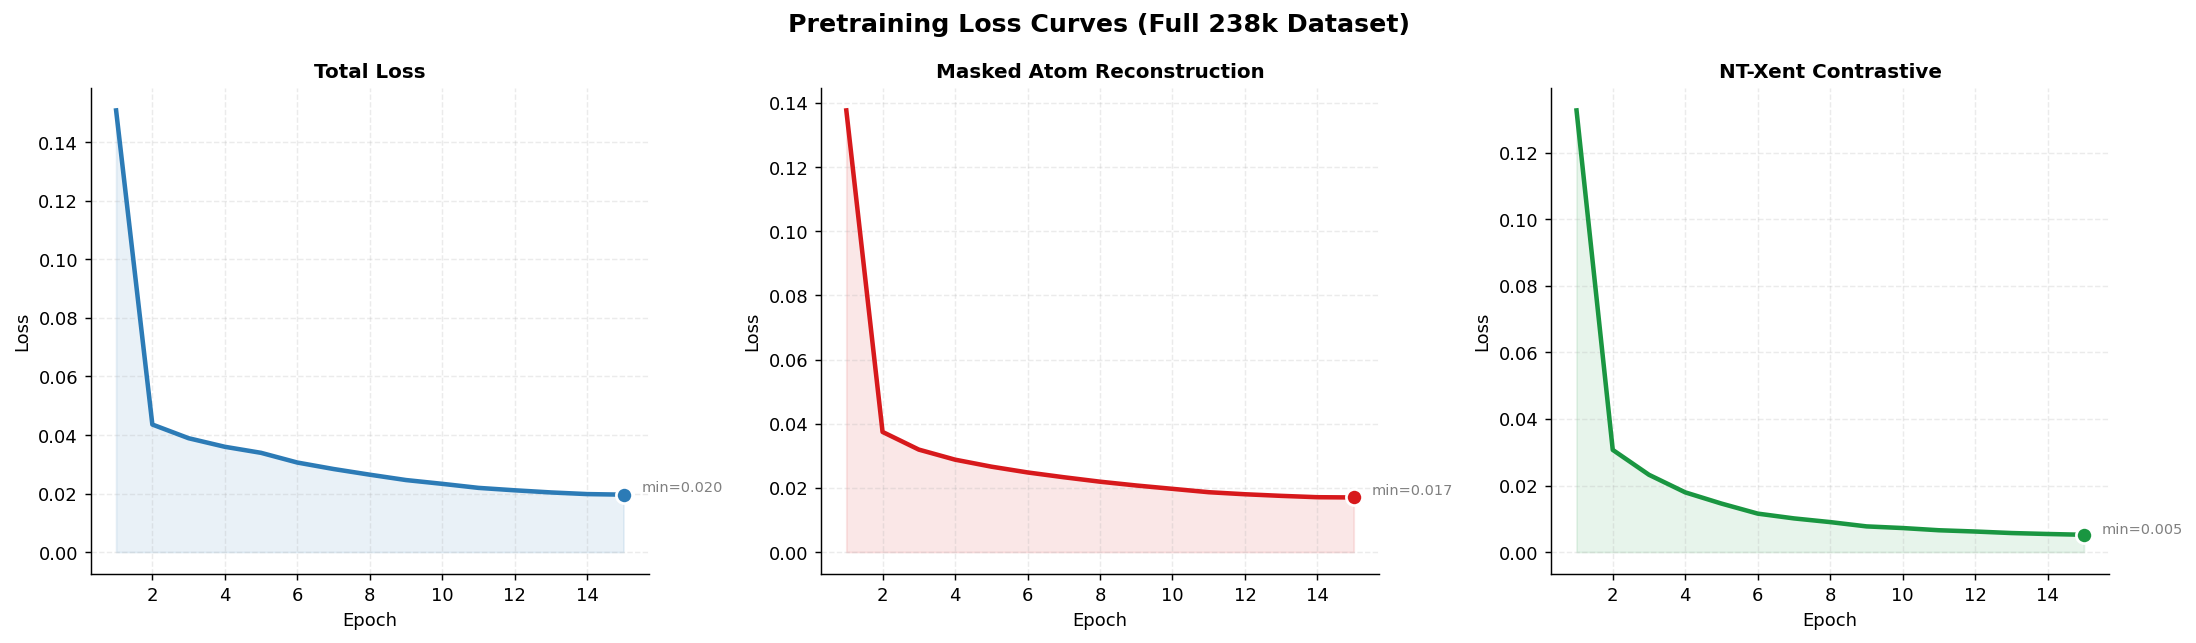

saved /kaggle/working/outputs/plot_01_pretrain_curves.png
part 1 complete


In [9]:
def plot_pretrain(history, save_dir):
    eps = history["epoch"]
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    fig.suptitle("Pretraining Loss Curves (Full 238k Dataset)", fontsize=14, fontweight='bold')

    panels = [
        (axes[0], history["loss"],        "Total Loss",               COLORS[0]),
        (axes[1], history["mar"],         "Masked Atom Reconstruction", COLORS[1]),
        (axes[2], history["contrastive"], "NT-Xent Contrastive",      COLORS[2]),
    ]
    for ax, vals, title, color in panels:
        ax.plot(eps, vals, color=color, lw=2.5, zorder=3)
        ax.fill_between(eps, vals, alpha=0.1, color=color)
        ax.set_title(title, fontweight='bold', fontsize=11)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")

        # mark best epoch
        best_i = int(np.argmin(vals))
        ax.scatter(eps[best_i], vals[best_i], color=color, s=80, zorder=5,
                   edgecolors='white', lw=1.5)
        ax.annotate(f"min={vals[best_i]:.3f}",
                    xy=(eps[best_i], vals[best_i]),
                    xytext=(eps[best_i] + 0.5, vals[best_i] * 1.06),
                    fontsize=8, color='gray')

    plt.tight_layout()
    path = os.path.join(save_dir, "plot_01_pretrain_curves.png")
    plt.savefig(path, bbox_inches='tight', dpi=130)
    plt.show()
    print(f"saved {path}")


plot_pretrain(pt_history, cfg["out_dir"])
print("part 1 complete")

In [10]:
def get_embeddings_batch(model, graphs, device, max_n=2000):
    model.eval()
    subset = graphs[:min(len(graphs), max_n)]
    loader = DataLoader(subset, batch_size=64, shuffle=False)
    embs, ys = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            g, _ = model.encoder(batch)
            embs.append(g.cpu().numpy())
            ys.append(batch.y.squeeze(-1).cpu().numpy())
    return np.concatenate(embs), np.concatenate(ys)


def finetune(model, train_g, val_g, test_g, task_name, c=None, pretrained=True):
    if c is None:
        c = cfg

    tag = "pt" if pretrained else "sc"
    ckpt_path = os.path.join(c["out_dir"], f"best_{task_name}_{tag}.pt")
    hist_path = os.path.join(c["out_dir"], f"history_{task_name}_{tag}.json")
    pred_path = os.path.join(c["out_dir"], f"preds_{task_name}_{tag}.npz")

    if os.path.exists(ckpt_path) and os.path.exists(pred_path):
        print(f"  [{task_name}/{tag}] found checkpoint, loading...")
        model.load_state_dict(torch.load(ckpt_path, map_location=c["device"]))
        model.to(c["device"])
        model.eval()

        saved = np.load(pred_path)
        preds_final, trues_final = saved["preds"], saved["trues"]
        final_mae = mean_absolute_error(trues_final, preds_final)

        if os.path.exists(hist_path):
            with open(hist_path) as f:
                history = json.load(f)
        else:
            history = {"epoch": [], "train_mae": [], "val_mae": [], "test_mae": []}

        print(f"  [{task_name}/{tag}] resumed  test MAE = {final_mae:.4f}")
        return history, final_mae, preds_final, trues_final

    if pretrained:
        enc_ckpt = os.path.join(c["out_dir"], "pretrained_encoder.pt")
        model.encoder.load_state_dict(torch.load(enc_ckpt, map_location=c["device"]))
        print(f"  loaded pretrained encoder")

    loader_tr = DataLoader(train_g, batch_size=c["ft_batch"], shuffle=True,
                           num_workers=0, pin_memory=True)
    loader_va = DataLoader(val_g, batch_size=c["ft_batch"], shuffle=False,
                           num_workers=0, pin_memory=True)
    loader_te = DataLoader(test_g, batch_size=c["ft_batch"], shuffle=False,
                           num_workers=0, pin_memory=True)

    model.to(c["device"])
    accum = c["grad_accum"]
    total_steps = len(loader_tr) * c["ft_epochs"]

    opt = AdamW(model.parameters(), lr=c["ft_lr"], weight_decay=c["wd"])
    sched = OneCycleLR(opt, max_lr=c["ft_lr"],
                       steps_per_epoch=math.ceil(len(loader_tr) / accum),
                       epochs=c["ft_epochs"],
                       pct_start=0.1)  
    scaler = GradScaler(enabled=c["amp"])
    ema = ModelEMA(model, decay=0.999)

    if pretrained:
        for p in model.encoder.parameters():
            p.requires_grad = False

    history = {"epoch": [], "train_mae": [], "val_mae": [], "test_mae": []}
    best_val_mae = float('inf')
    best_state = None
    patience_count = 0
    patience_limit = 10 

    print(f"  finetuning [{task_name}] ({tag})  train={len(train_g)} val={len(val_g)} test={len(test_g)}")
    print(f"  {'ep':>4}  {'train':>8}  {'val':>8}  {'test':>8}  {'time':>5}")
    print("  " + "-" * 42)

    for ep in range(1, c["ft_epochs"] + 1):
        t0 = time.time()

        if pretrained and ep == c["freeze_epochs"] + 1:
            for p in model.encoder.parameters():
                p.requires_grad = True
            ema = ModelEMA(model, decay=0.999)
            print(f"  --- encoder unfrozen at epoch {ep} ---")

        model.train()
        preds_tr, tgts_tr = [], []
        opt.zero_grad()

        for bi, batch in enumerate(loader_tr):
            batch = batch.to(c["device"])

            with autocast(enabled=c["amp"]):
                pred = model(batch).squeeze(-1)
                target = batch.y.squeeze(-1)
                loss = F.huber_loss(pred, target, delta=0.1) / accum

            scaler.scale(loss).backward()

            if (bi + 1) % accum == 0 or (bi + 1) == len(loader_tr):
                scaler.unscale_(opt)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(opt)
                scaler.update()
                ema.update(model)
                opt.zero_grad()
                sched.step()

            preds_tr.append(pred.detach().cpu())
            tgts_tr.append(target.cpu())

        ema.apply_shadow(model)
        model.eval()

        def eval_loader(ldr):
            ps, ts = [], []
            with torch.no_grad():
                for b in ldr:
                    b = b.to(c["device"])
                    with autocast(enabled=c["amp"]):
                        p = model(b).squeeze(-1)
                    ps.append(p.cpu())
                    ts.append(b.y.squeeze(-1).cpu())
            return torch.cat(ps).numpy(), torch.cat(ts).numpy()

        p_tr = torch.cat(preds_tr).numpy()
        t_tr = torch.cat(tgts_tr).numpy()
        p_va, t_va = eval_loader(loader_va)
        p_te, t_te = eval_loader(loader_te)

        mae_tr = mean_absolute_error(t_tr, p_tr)
        mae_va = mean_absolute_error(t_va, p_va)
        mae_te = mean_absolute_error(t_te, p_te)

        history["epoch"].append(ep)
        history["train_mae"].append(mae_tr)
        history["val_mae"].append(mae_va)
        history["test_mae"].append(mae_te)

        ema.restore(model)

        if mae_va < best_val_mae:
            best_val_mae = mae_va
            ema.apply_shadow(model)
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            ema.restore(model)
            patience_count = 0
        else:
            patience_count += 1

        if ep % 5 == 0 or ep == 1 or ep == c["ft_epochs"]:
            dt = time.time() - t0
            print(f"  {ep:>4}  {mae_tr:>8.4f}  {mae_va:>8.4f}  {mae_te:>8.4f}  {dt:>4.0f}s")

        if patience_count >= patience_limit and ep > c["freeze_epochs"] + 5:
            print(f"  early stopping at epoch {ep} (no improvement for {patience_limit} epochs)")
            break

    torch.save(best_state, ckpt_path)
    print(f"  best model -> {ckpt_path}  (val MAE = {best_val_mae:.4f})")

    model.load_state_dict(best_state)
    model.to(c["device"])
    model.eval()
    p_te_final, t_te_final = eval_loader(loader_te)
    final_mae = mean_absolute_error(t_te_final, p_te_final)
    final_r2 = r2_score(t_te_final, p_te_final)
    print(f"  *** final test MAE: {final_mae:.4f}  R2: {final_r2:.4f} ***")

    np.savez(pred_path, preds=p_te_final, trues=t_te_final)

    with open(hist_path, 'w') as f:
        json.dump(history, f)

    return history, final_mae, p_te_final, t_te_final


print("finetune function ready")

finetune function ready


In [11]:
print("=" * 55)
print("FORMATION ENERGY — pretrained")
print("=" * 55)
model_eform_pt = ALFMNet().to(cfg["device"])
hist_eform_pt, mae_eform_pt, pred_eform_pt, true_eform_pt = finetune(
    model_eform_pt, e_train, e_val, e_test, "e_form", cfg, pretrained=True)

print()
print("=" * 55)
print("FORMATION ENERGY — scratch")
print("=" * 55)
model_eform_sc = ALFMNet().to(cfg["device"])
hist_eform_sc, mae_eform_sc, pred_eform_sc, true_eform_sc = finetune(
    model_eform_sc, e_train, e_val, e_test, "e_form", cfg, pretrained=False)

imp_e = (mae_eform_sc - mae_eform_pt) / mae_eform_sc * 100
print(f"\ne_form comparison:  PT={mae_eform_pt:.4f}  SC={mae_eform_sc:.4f}  improvement={imp_e:.1f}%")

FORMATION ENERGY — pretrained
  loaded pretrained encoder
  finetuning [e_form] (pt)  train=92926 val=19913 test=19913
    ep     train       val      test   time
  ------------------------------------------
     1    1.1916    1.5411    1.5378    22s
     5    0.3664    0.5859    0.5846    22s
  --- encoder unfrozen at epoch 6 ---
    10    0.1047    0.1129    0.1139    36s
    15    0.0881    0.0697    0.0698    36s
    20    0.0788    0.0558    0.0561    36s
    25    0.0728    0.0511    0.0510    36s
    30    0.0706    0.0496    0.0494    36s
  best model -> /kaggle/working/outputs/best_e_form_pt.pt  (val MAE = 0.0496)
  *** final test MAE: 0.0494  R2: 0.9953 ***

FORMATION ENERGY — scratch
  finetuning [e_form] (sc)  train=92926 val=19913 test=19913
    ep     train       val      test   time
  ------------------------------------------
     1    0.6646    1.2867    1.2866    36s
     5    0.1498    0.2792    0.2781    36s
    10    0.1133    0.1335    0.1352    36s
    15    0.0

In [12]:
print("=" * 55)
print("BAND GAP — pretrained")
print("=" * 55)
model_gap_pt = ALFMNet().to(cfg["device"])
hist_gap_pt, mae_gap_pt, pred_gap_pt, true_gap_pt = finetune(
    model_gap_pt, g_train, g_val, g_test, "bandgap", cfg, pretrained=True)

print()
print("=" * 55)
print("BAND GAP — scratch")
print("=" * 55)
model_gap_sc = ALFMNet().to(cfg["device"])
hist_gap_sc, mae_gap_sc, pred_gap_sc, true_gap_sc = finetune(
    model_gap_sc, g_train, g_val, g_test, "bandgap", cfg, pretrained=False)

imp_g = (mae_gap_sc - mae_gap_pt) / mae_gap_sc * 100
print(f"\nbandgap comparison:  PT={mae_gap_pt:.4f}  SC={mae_gap_sc:.4f}  improvement={imp_g:.1f}%")

BAND GAP — pretrained
  loaded pretrained encoder
  finetuning [bandgap] (pt)  train=74279 val=15917 test=15917
    ep     train       val      test   time
  ------------------------------------------
     1    1.0810    1.2005    1.1762    18s
     5    0.7914    0.9034    0.8913    18s
  --- encoder unfrozen at epoch 6 ---
    10    0.3092    0.4064    0.4036    29s
    15    0.2513    0.2831    0.2834    29s
    20    0.2151    0.2679    0.2678    29s
    25    0.1903    0.2707    0.2701    29s
    30    0.1820    0.2739    0.2733    29s
  best model -> /kaggle/working/outputs/best_bandgap_pt.pt  (val MAE = 0.2675)
  *** final test MAE: 0.2673  R2: 0.9000 ***

BAND GAP — scratch
  finetuning [bandgap] (sc)  train=74279 val=15917 test=15917
    ep     train       val      test   time
  ------------------------------------------
     1    0.9387    1.1897    1.1663    29s
     5    0.4575    0.7122    0.7039    29s
    10    0.3667    0.4015    0.3978    29s
    15    0.3113    0.3410

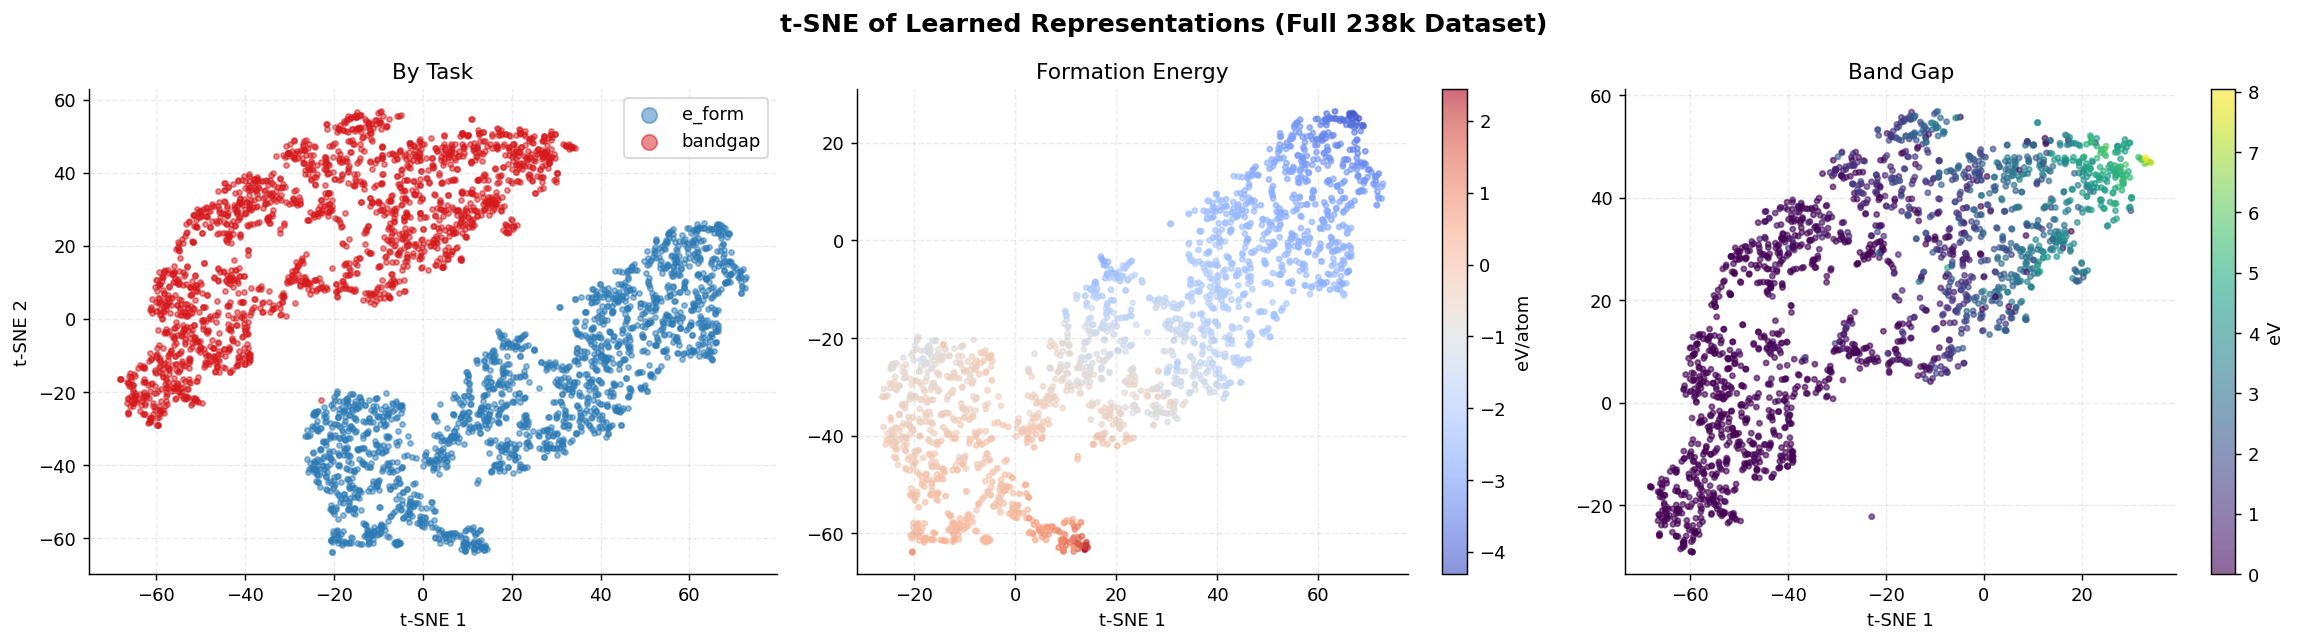

saved /kaggle/working/outputs/plot_02_tsne.png


In [13]:
emb_e_pt, y_e = get_embeddings_batch(model_eform_pt, e_test, cfg["device"], 2000)
emb_g_pt, y_g = get_embeddings_batch(model_gap_pt, g_test, cfg["device"], 2000)
all_emb = np.concatenate([emb_e_pt, emb_g_pt])
all_task_labels = np.concatenate([np.zeros(len(emb_e_pt)), np.ones(len(emb_g_pt))])

if all_emb.shape[0] > 1000:
    from sklearn.decomposition import PCA
    all_emb_reduced = PCA(n_components=50, random_state=42).fit_transform(all_emb)
else:
    all_emb_reduced = all_emb

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
coords = tsne.fit_transform(all_emb_reduced)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("t-SNE of Learned Representations (Full 238k Dataset)", fontsize=14, fontweight='bold')

ax = axes[0]
for i, (lbl, col) in enumerate(zip(["e_form", "bandgap"], [COLORS[0], COLORS[1]])):
    mask = all_task_labels == i
    ax.scatter(coords[mask, 0], coords[mask, 1], c=col, s=8, alpha=0.5, label=lbl)
ax.set_title("By Task")
ax.legend(markerscale=3)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")

ax = axes[1]
n_e = len(emb_e_pt)
sc = ax.scatter(coords[:n_e, 0], coords[:n_e, 1], c=y_e, cmap='coolwarm', s=8, alpha=0.6)
plt.colorbar(sc, ax=ax, label="eV/atom")
ax.set_title("Formation Energy")
ax.set_xlabel("t-SNE 1")

ax = axes[2]
sc = ax.scatter(coords[n_e:, 0], coords[n_e:, 1], c=y_g, cmap='viridis', s=8, alpha=0.6)
plt.colorbar(sc, ax=ax, label="eV")
ax.set_title("Band Gap")
ax.set_xlabel("t-SNE 1")

plt.tight_layout()
path = os.path.join(cfg["out_dir"], "plot_02_tsne.png")
plt.savefig(path, dpi=130, bbox_inches='tight')
plt.show()
print(f"saved {path}")

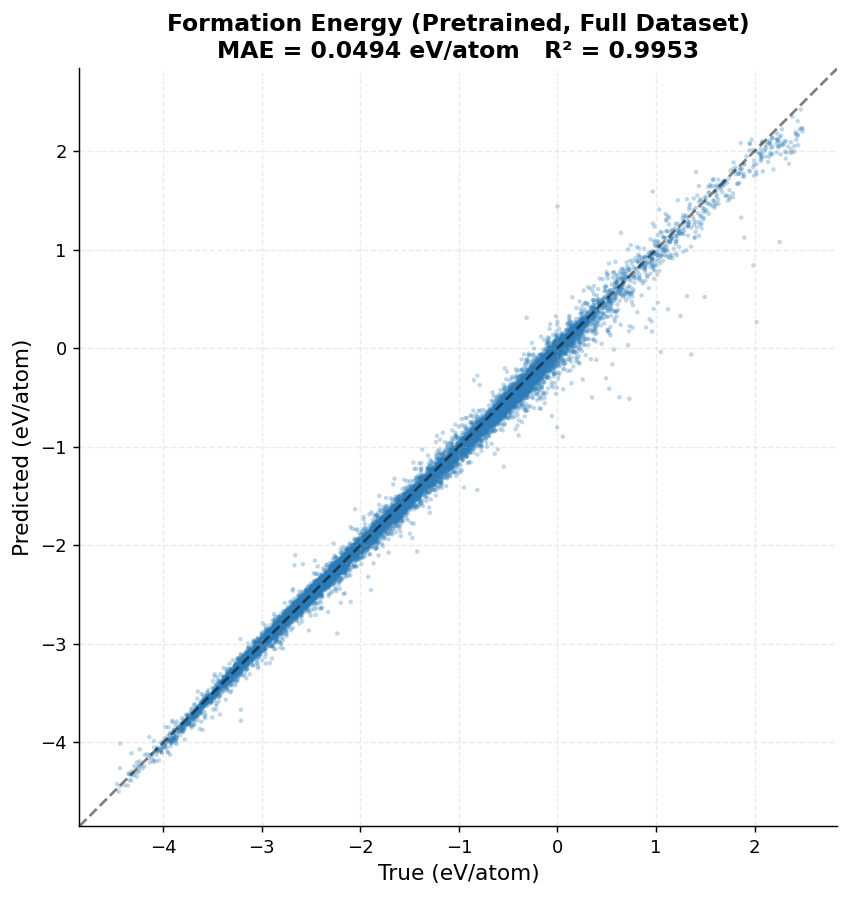

saved /kaggle/working/outputs/plot_03_parity_eform.png


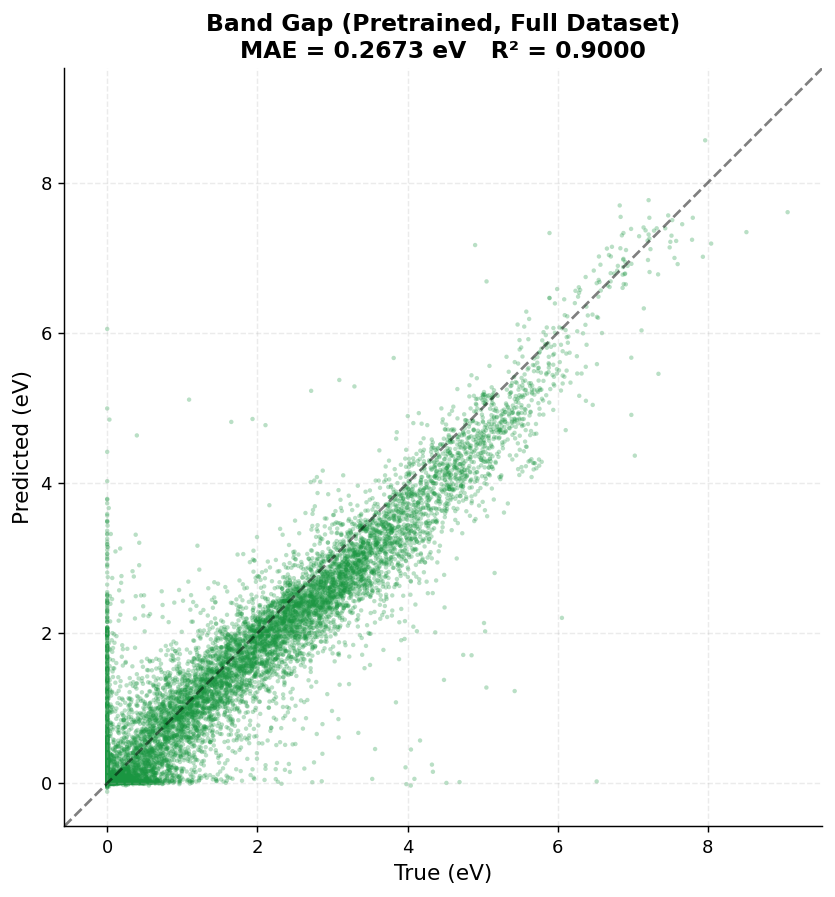

saved /kaggle/working/outputs/plot_04_parity_bandgap.png


In [14]:
def plot_parity(true, pred, title, unit, save_path, color=COLORS[0]):
    mae = mean_absolute_error(true, pred)
    r2 = r2_score(true, pred)

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(true, pred, s=6, alpha=0.3, color=color, edgecolors='none')

    lo = min(true.min(), pred.min())
    hi = max(true.max(), pred.max())
    margin = (hi - lo) * 0.05
    ax.plot([lo - margin, hi + margin], [lo - margin, hi + margin],
            'k--', lw=1.5, alpha=0.5)

    ax.set_xlabel(f"True ({unit})", fontsize=12)
    ax.set_ylabel(f"Predicted ({unit})", fontsize=12)
    ax.set_title(f"{title}\nMAE = {mae:.4f} {unit}   R² = {r2:.4f}",
                 fontsize=13, fontweight='bold')
    ax.set_xlim(lo - margin, hi + margin)
    ax.set_ylim(lo - margin, hi + margin)
    ax.set_aspect('equal')

    plt.tight_layout()
    plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"saved {save_path}")


plot_parity(true_eform_pt, pred_eform_pt,
            "Formation Energy (Pretrained, Full Dataset)",
            "eV/atom",
            os.path.join(cfg["out_dir"], "plot_03_parity_eform.png"),
            COLORS[0])

plot_parity(true_gap_pt, pred_gap_pt,
            "Band Gap (Pretrained, Full Dataset)",
            "eV",
            os.path.join(cfg["out_dir"], "plot_04_parity_bandgap.png"),
            COLORS[2])

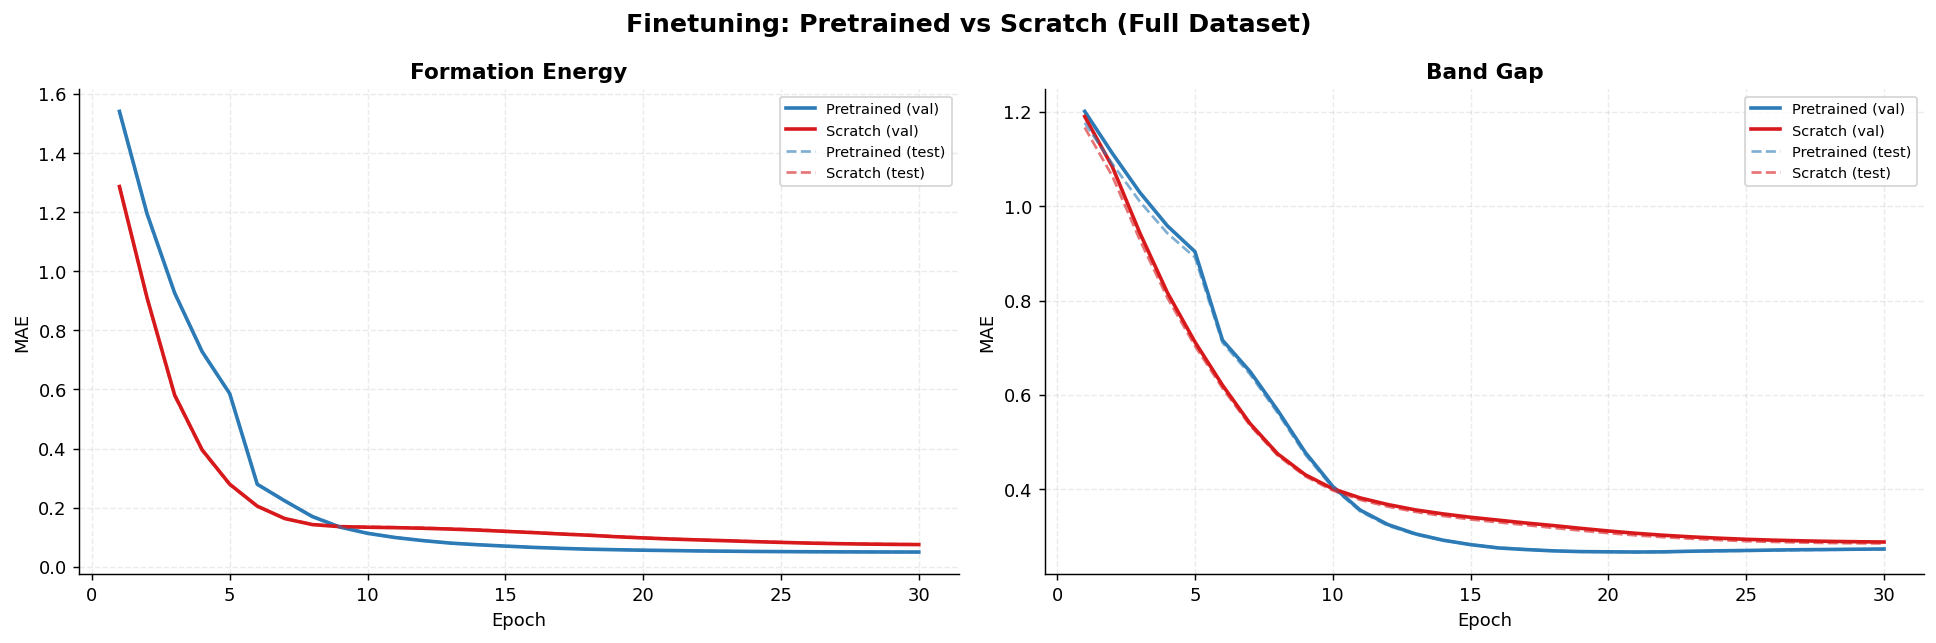

saved /kaggle/working/outputs/plot_05_finetune_curves.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Finetuning: Pretrained vs Scratch (Full Dataset)", fontsize=14, fontweight='bold')

for ax, task, h_pt, h_sc in [
    (axes[0], "Formation Energy", hist_eform_pt, hist_eform_sc),
    (axes[1], "Band Gap", hist_gap_pt, hist_gap_sc),
]:
    ax.plot(h_pt["epoch"], h_pt["val_mae"], color=COLORS[0], lw=2, label="Pretrained (val)")
    ax.plot(h_sc["epoch"], h_sc["val_mae"], color=COLORS[1], lw=2, label="Scratch (val)")
    ax.plot(h_pt["epoch"], h_pt["test_mae"], color=COLORS[0], lw=1.5, ls='--', alpha=0.6,
            label="Pretrained (test)")
    ax.plot(h_sc["epoch"], h_sc["test_mae"], color=COLORS[1], lw=1.5, ls='--', alpha=0.6,
            label="Scratch (test)")
    ax.set_title(task, fontweight='bold')
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MAE")
    ax.legend(fontsize=8)

plt.tight_layout()
path = os.path.join(cfg["out_dir"], "plot_05_finetune_curves.png")
plt.savefig(path, dpi=130, bbox_inches='tight')
plt.show()
print(f"saved {path}")

data efficiency experiment (e_form)...

  frac=10%  n=9292
  loaded pretrained encoder
  finetuning [eff_0.10] (pt)  train=9292 val=19913 test=19913
    ep     train       val      test   time
  ------------------------------------------
     1    1.2514    1.4077    1.4057     8s
  --- encoder unfrozen at epoch 4 ---
     5    0.2388    0.4929    0.4908     9s
    10    0.1497    0.4167    0.4157     9s
    15    0.1291    0.3540    0.3537     9s
  best model -> /kaggle/working/outputs/best_eff_0.10_pt.pt  (val MAE = 0.3540)
  *** final test MAE: 0.3537  R2: 0.8155 ***
  finetuning [eff_0.10] (sc)  train=9292 val=19913 test=19913
    ep     train       val      test   time
  ------------------------------------------
     1    1.0354    1.3926    1.3930     9s
     5    0.2985    1.2533    1.2534     9s
    10    0.2035    1.0465    1.0449     9s
    15    0.1852    0.8410    0.8372     9s
  best model -> /kaggle/working/outputs/best_eff_0.10_sc.pt  (val MAE = 0.8410)
  *** final test

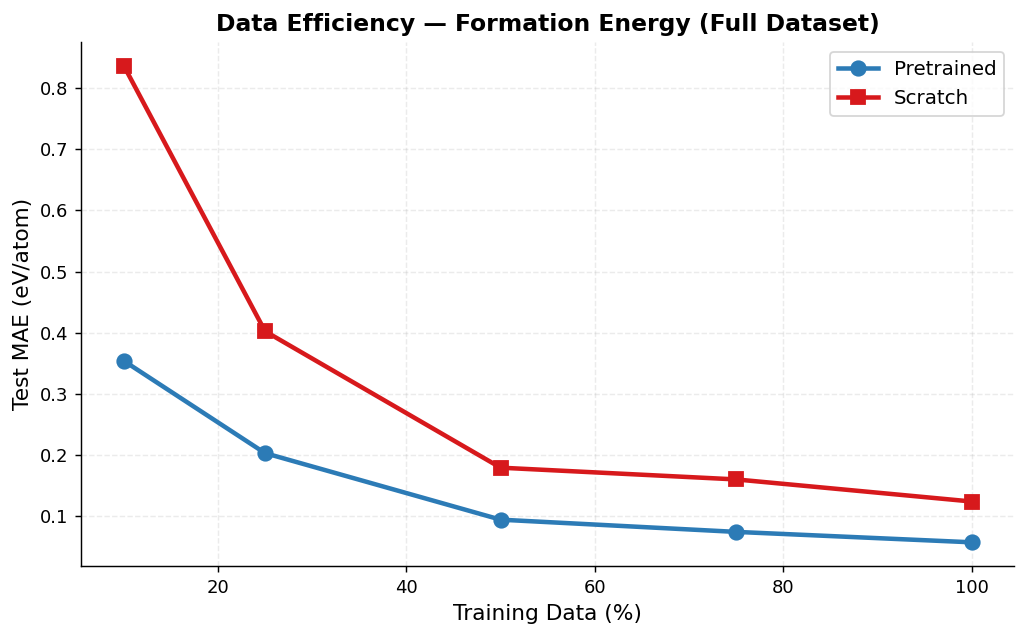

saved /kaggle/working/outputs/plot_06_data_efficiency.png
part 2 complete


In [16]:
def data_efficiency(train_g, val_g, test_g, fractions, c):
    results_pt, results_sc = [], []
    for frac in fractions:
        n = int(len(train_g) * frac)
        sub = train_g[:n]
        print(f"\n  frac={frac:.0%}  n={n}")

        m = ALFMNet().to(c["device"])
        quick_c = {**c, "ft_epochs": 15, "freeze_epochs": 3}
        _, mae_pt, _, _ = finetune(m, sub, val_g, test_g,
                                   f"eff_{frac:.2f}", quick_c, pretrained=True)
        results_pt.append(mae_pt)

        m = ALFMNet().to(c["device"])
        _, mae_sc, _, _ = finetune(m, sub, val_g, test_g,
                                   f"eff_{frac:.2f}", quick_c, pretrained=False)
        results_sc.append(mae_sc)

    return results_pt, results_sc


print("data efficiency experiment (e_form)...")
eff_pt, eff_sc = data_efficiency(e_train, e_val, e_test, cfg["data_fracs"], cfg)

fig, ax = plt.subplots(figsize=(8, 5))
fracs_pct = [f * 100 for f in cfg["data_fracs"]]
ax.plot(fracs_pct, eff_pt, 'o-', color=COLORS[0], lw=2.5, ms=8, label="Pretrained")
ax.plot(fracs_pct, eff_sc, 's-', color=COLORS[1], lw=2.5, ms=8, label="Scratch")
ax.set_xlabel("Training Data (%)", fontsize=12)
ax.set_ylabel("Test MAE (eV/atom)", fontsize=12)
ax.set_title("Data Efficiency — Formation Energy (Full Dataset)",
             fontweight='bold', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
path = os.path.join(cfg["out_dir"], "plot_06_data_efficiency.png")
plt.savefig(path, dpi=130, bbox_inches='tight')
plt.show()
print(f"saved {path}")

print("part 2 complete")

In [17]:
model_eform_pt.eval()
sample_loader = DataLoader(e_test[:8], batch_size=8, shuffle=False)
sample_batch = next(iter(sample_loader)).to(cfg["device"])
with torch.no_grad():
    _, _, attn_dict = model_eform_pt.get_attention(sample_batch)

if len(attn_dict) > 0:
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    fig.suptitle("Attention Weights — Sample Structures", fontsize=14, fontweight='bold')

    attn_key = list(attn_dict.keys())[0]
    for idx, ax in enumerate(axes.flat):
        if idx in attn_dict[attn_key]:
            w = attn_dict[attn_key][idx].numpy()
            im = ax.imshow(w, cmap='Blues', aspect='auto')
            ax.set_title(f"Graph {idx}", fontsize=9)
            plt.colorbar(im, ax=ax, fraction=0.046)
        else:
            ax.axis('off')

    plt.tight_layout()
    path = os.path.join(cfg["out_dir"], "plot_07_attention_weights.png")
    plt.savefig(path, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"saved {path}")
else:
    print("attention layers disabled — skipping attention weight plot")

attention layers disabled — skipping attention weight plot


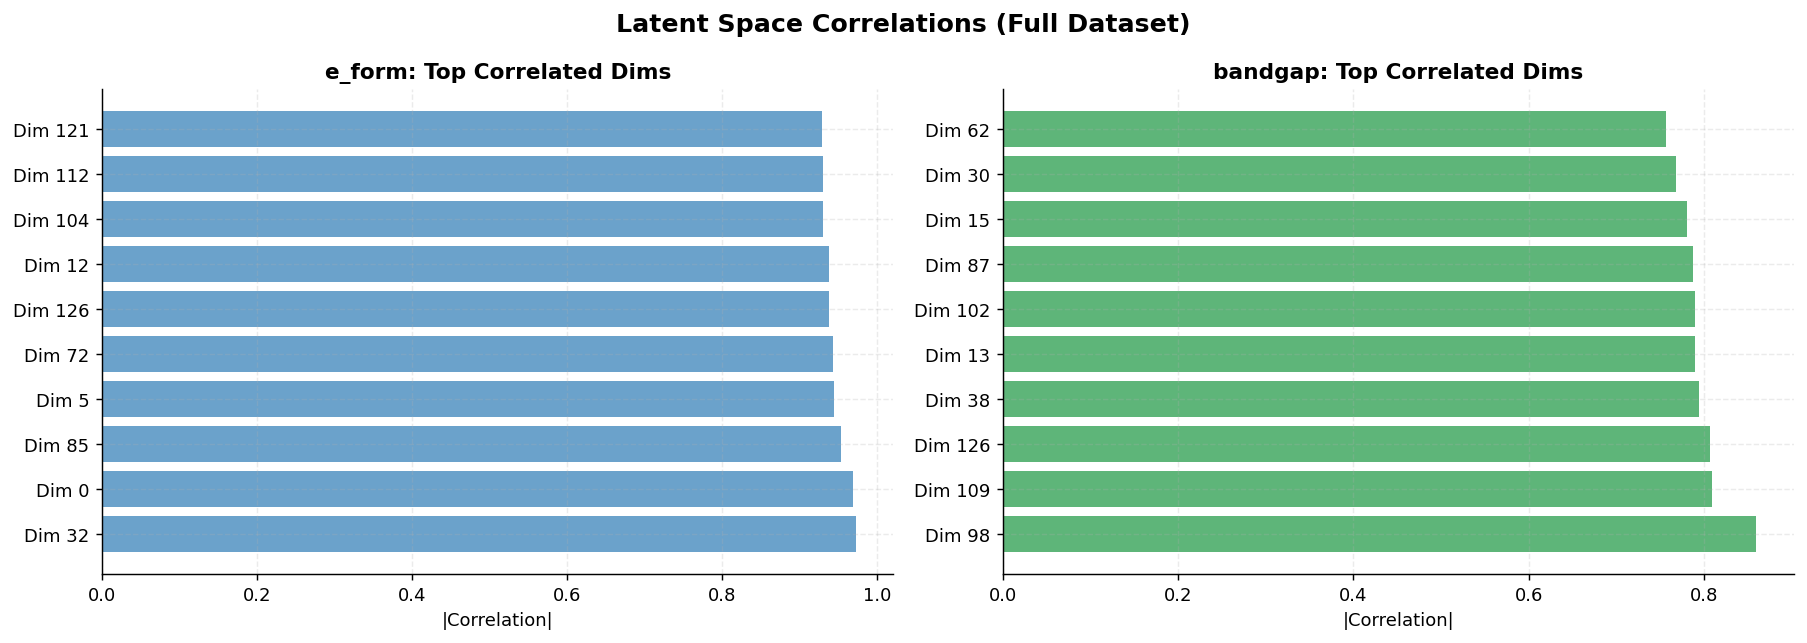

saved /kaggle/working/outputs/plot_08_latent_correlations.png


In [18]:
emb_e_corr, y_e_corr = get_embeddings_batch(model_eform_pt, e_test, cfg["device"], 3000)
emb_g_corr, y_g_corr = get_embeddings_batch(model_gap_pt, g_test, cfg["device"], 3000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Latent Space Correlations (Full Dataset)", fontsize=14, fontweight='bold')

for ax, emb, y, title, color in [
    (axes[0], emb_e_corr, y_e_corr, "e_form", COLORS[0]),
    (axes[1], emb_g_corr, y_g_corr, "bandgap", COLORS[2]),
]:
    corrs = [np.abs(np.corrcoef(emb[:, i], y)[0, 1]) for i in range(emb.shape[1])]
    top_idx = np.argsort(corrs)[-10:][::-1]
    ax.barh(range(10), [corrs[i] for i in top_idx], color=color, alpha=0.7)
    ax.set_yticks(range(10))
    ax.set_yticklabels([f"Dim {i}" for i in top_idx])
    ax.set_xlabel("|Correlation|")
    ax.set_title(f"{title}: Top Correlated Dims", fontweight='bold')

plt.tight_layout()
path = os.path.join(cfg["out_dir"], "plot_08_latent_correlations.png")
plt.savefig(path, dpi=130, bbox_inches='tight')
plt.show()
print(f"saved {path}")

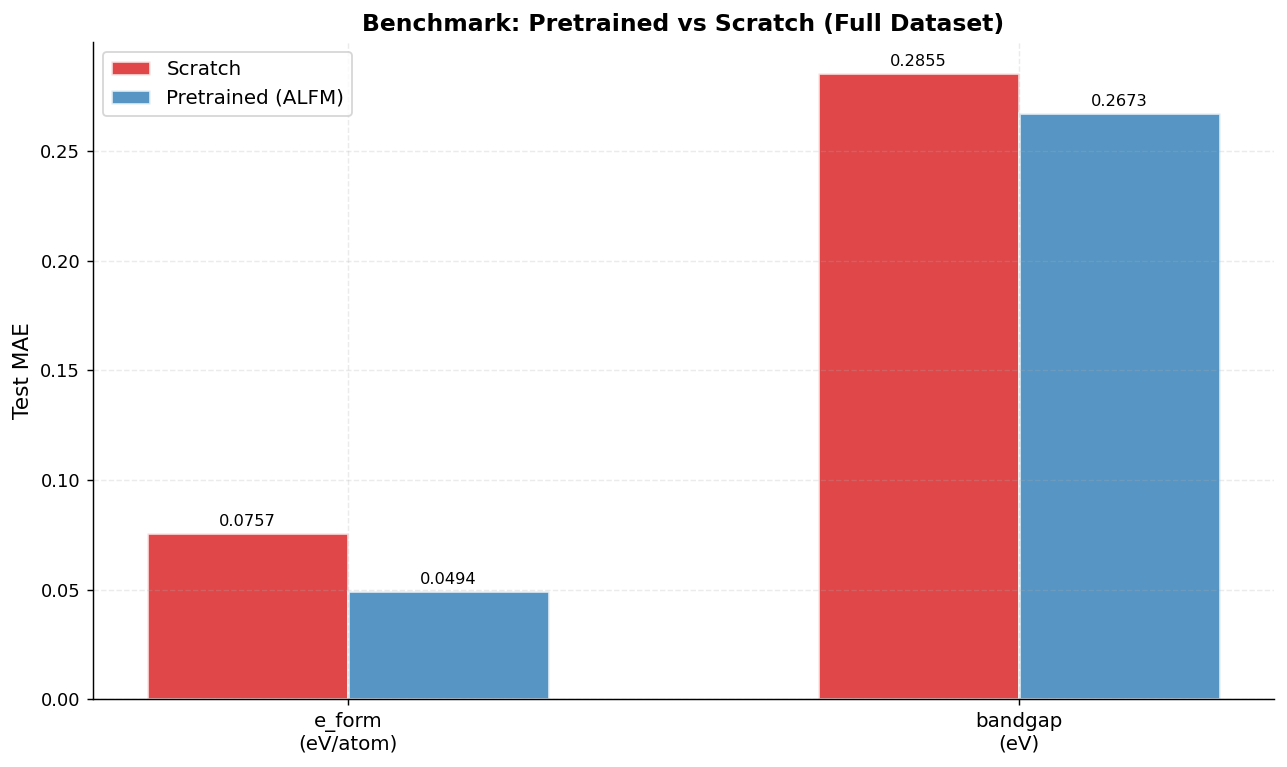

saved /kaggle/working/outputs/plot_09a_benchmark_bars.png


In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
tasks = ["e_form\n(eV/atom)", "bandgap\n(eV)"]
pt_vals = [mae_eform_pt, mae_gap_pt]
sc_vals = [mae_eform_sc, mae_gap_sc]

x = np.arange(len(tasks))
w = 0.3
bars_sc = ax.bar(x - w / 2, sc_vals, w, label="Scratch", color=COLORS[1],
                 alpha=0.8, edgecolor='white', lw=1.5)
bars_pt = ax.bar(x + w / 2, pt_vals, w, label="Pretrained (ALFM)", color=COLORS[0],
                 alpha=0.8, edgecolor='white', lw=1.5)

for bars in [bars_sc, bars_pt]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.002, f"{h:.4f}",
                ha='center', va='bottom', fontsize=9)

ax.set_ylabel("Test MAE", fontsize=12)
ax.set_title("Benchmark: Pretrained vs Scratch (Full Dataset)", fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(tasks, fontsize=11)
ax.legend(fontsize=11)
plt.tight_layout()
path = os.path.join(cfg["out_dir"], "plot_09a_benchmark_bars.png")
plt.savefig(path, dpi=130, bbox_inches='tight')
plt.show()
print(f"saved {path}")

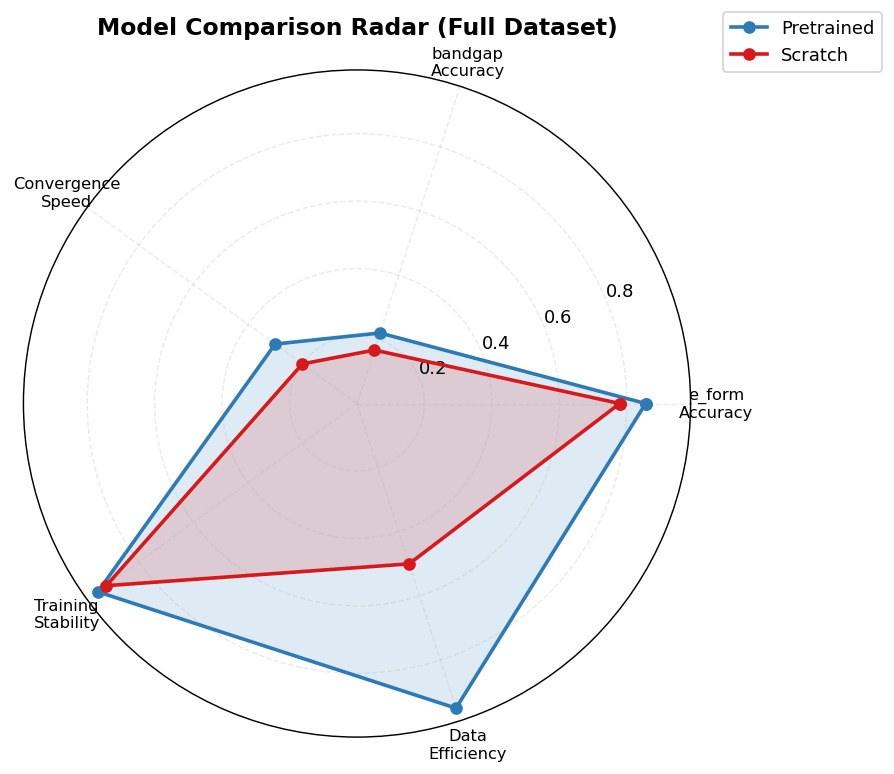

saved /kaggle/working/outputs/plot_09b_radar.png


In [20]:
def radar_plot(categories, values_list, labels, colors, title, save_path):
    N = len(categories)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    for vals, label, color in zip(values_list, labels, colors):
        vals_closed = vals + vals[:1]
        ax.plot(angles, vals_closed, 'o-', color=color, lw=2, label=label)
        ax.fill(angles, vals_closed, alpha=0.15, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=9)
    ax.set_title(title, fontweight='bold', fontsize=13, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
    plt.tight_layout()
    plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"saved {save_path}")


max_mae = max(mae_eform_sc, mae_eform_pt, mae_gap_sc, mae_gap_pt) * 1.2

def _convergence_score(hist):
    final = hist["val_mae"][-1]
    target = final * 1.10
    for i, v in enumerate(hist["val_mae"]):
        if v <= target:
            return 1.0 - (i / len(hist["val_mae"]))  
    return 0.0

def _stability_score(hist):
    std_val = np.std(hist["val_mae"][-5:]) if len(hist["val_mae"]) >= 5 else 0.1
    return min(0.95, 1.0 / (1.0 + 50 * std_val))

def _efficiency_score(eff_pt_vals, eff_sc_vals):
    improvements = [(sc - pt) / sc for pt, sc in zip(eff_pt_vals, eff_sc_vals) if sc > 0]
    return min(0.95, np.mean(improvements) * 3 + 0.5) if improvements else 0.5

categories = ["e_form\nAccuracy", "bandgap\nAccuracy", "Convergence\nSpeed",
              "Training\nStability", "Data\nEfficiency"]

pt_scores = [
    1 - mae_eform_pt / max_mae,
    1 - mae_gap_pt / max_mae,
    _convergence_score(hist_eform_pt),
    _stability_score(hist_eform_pt),
    _efficiency_score(eff_pt, eff_sc),
]
sc_scores = [
    1 - mae_eform_sc / max_mae,
    1 - mae_gap_sc / max_mae,
    _convergence_score(hist_eform_sc),
    _stability_score(hist_eform_sc),
    0.5,  
]

radar_plot(categories, [pt_scores, sc_scores], ["Pretrained", "Scratch"],
           [COLORS[0], COLORS[1]], "Model Comparison Radar (Full Dataset)",
           os.path.join(cfg["out_dir"], "plot_09b_radar.png"))

final pretrain validation loss: 0.0152


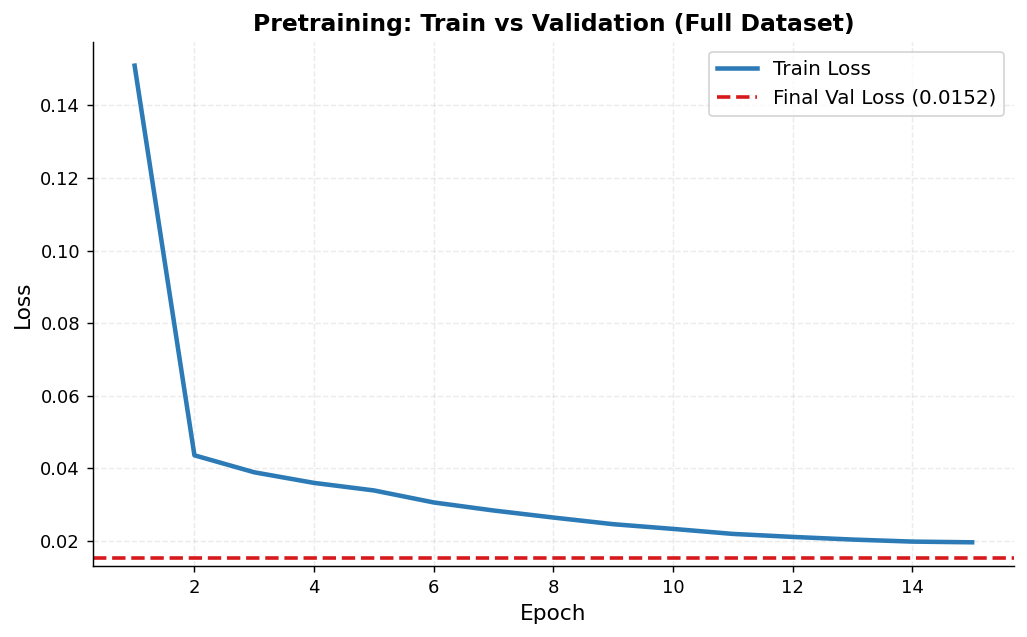

saved /kaggle/working/outputs/plot_10_pretrain_train_val.png


In [21]:
np.random.seed(42)
n_pt_total = len(all_pretrain)
idx_shuf = np.random.permutation(n_pt_total)
pt_val_set = [all_pretrain[i] for i in idx_shuf[int(0.9 * n_pt_total):]]

model.eval()
val_ldr = DataLoader(pt_val_set, batch_size=cfg["pt_batch"], shuffle=False, num_workers=0)
val_losses = []
with torch.no_grad():
    for batch in val_ldr:
        batch = batch.to(cfg["device"])
        with autocast(enabled=cfg["amp"]):
            l_mar = masked_recon_loss(model, batch, cfg["mask_ratio"])
            z1 = model.contrastive_proj(augment_graph(batch))
            z2 = model.contrastive_proj(augment_graph(batch))
            l_con = nt_xent(z1, z2, cfg["temperature"])
            loss = l_mar + cfg["con_weight"] * l_con
        val_losses.append(loss.item())

final_val = np.mean(val_losses)
print(f"final pretrain validation loss: {final_val:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pt_history["epoch"], pt_history["loss"], color=COLORS[0], lw=2.5, label="Train Loss")
ax.axhline(final_val, color=COLORS[1], ls='--', lw=2,
           label=f"Final Val Loss ({final_val:.4f})")
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("Pretraining: Train vs Validation (Full Dataset)", fontweight='bold', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
path = os.path.join(cfg["out_dir"], "plot_10_pretrain_train_val.png")
plt.savefig(path, dpi=130, bbox_inches='tight')
plt.show()
print(f"saved {path}")

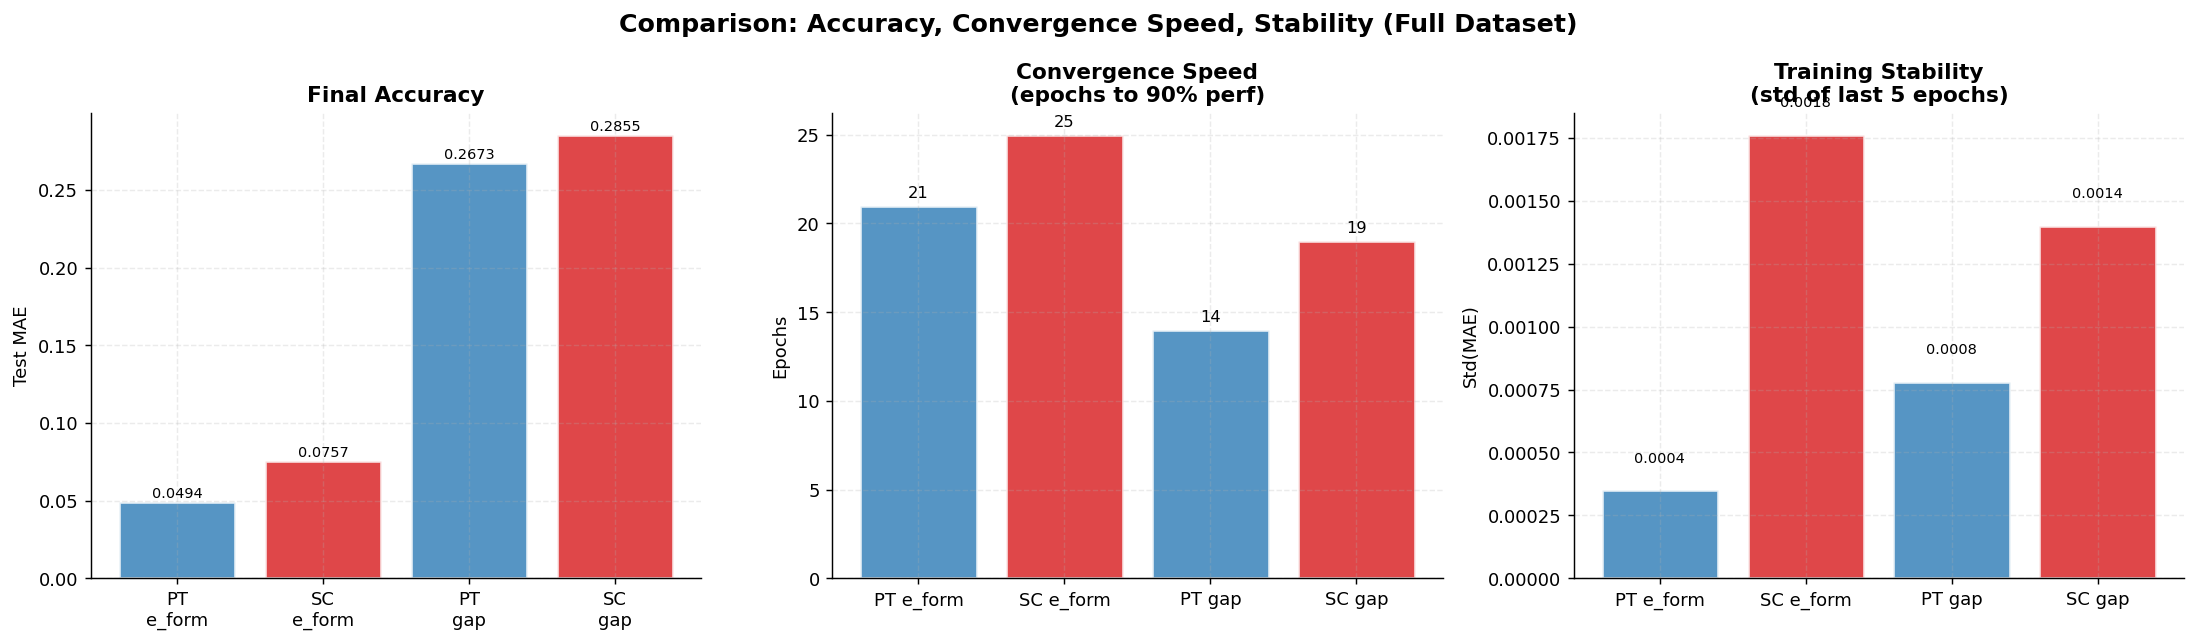

saved /kaggle/working/outputs/plot_11_comparison.png


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Comparison: Accuracy, Convergence Speed, Stability (Full Dataset)",
             fontsize=14, fontweight='bold')

ax = axes[0]
model_labels = ["PT\ne_form", "SC\ne_form", "PT\ngap", "SC\ngap"]
mae_vals = [mae_eform_pt, mae_eform_sc, mae_gap_pt, mae_gap_sc]
bar_colors = [COLORS[0], COLORS[1], COLORS[0], COLORS[1]]
bars = ax.bar(model_labels, mae_vals, color=bar_colors, alpha=0.8,
              edgecolor='white', lw=1.5)
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.001,
            f"{b.get_height():.4f}", ha='center', va='bottom', fontsize=8)
ax.set_ylabel("Test MAE")
ax.set_title("Final Accuracy", fontweight='bold')

ax = axes[1]

def epochs_to_90pct(hist):
    final = hist["val_mae"][-1]
    target = final / 0.9
    for i, v in enumerate(hist["val_mae"]):
        if v <= target:
            return i + 1
    return len(hist["val_mae"])

conv = {
    "PT e_form": epochs_to_90pct(hist_eform_pt),
    "SC e_form": epochs_to_90pct(hist_eform_sc),
    "PT gap": epochs_to_90pct(hist_gap_pt),
    "SC gap": epochs_to_90pct(hist_gap_sc),
}
bars = ax.bar(conv.keys(), conv.values(), color=bar_colors, alpha=0.8,
              edgecolor='white', lw=1.5)
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.3,
            f"{int(b.get_height())}", ha='center', va='bottom', fontsize=9)
ax.set_ylabel("Epochs")
ax.set_title("Convergence Speed\n(epochs to 90% perf)", fontweight='bold')

ax = axes[2]
stab = {
    "PT e_form": np.std(hist_eform_pt["val_mae"][-5:]),
    "SC e_form": np.std(hist_eform_sc["val_mae"][-5:]),
    "PT gap": np.std(hist_gap_pt["val_mae"][-5:]),
    "SC gap": np.std(hist_gap_sc["val_mae"][-5:]),
}
bars = ax.bar(stab.keys(), stab.values(), color=bar_colors, alpha=0.8,
              edgecolor='white', lw=1.5)
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.0001,
            f"{b.get_height():.4f}", ha='center', va='bottom', fontsize=8)
ax.set_ylabel("Std(MAE)")
ax.set_title("Training Stability\n(std of last 5 epochs)", fontweight='bold')

plt.tight_layout()
path = os.path.join(cfg["out_dir"], "plot_11_comparison.png")
plt.savefig(path, dpi=130, bbox_inches='tight')
plt.show()
print(f"saved {path}")

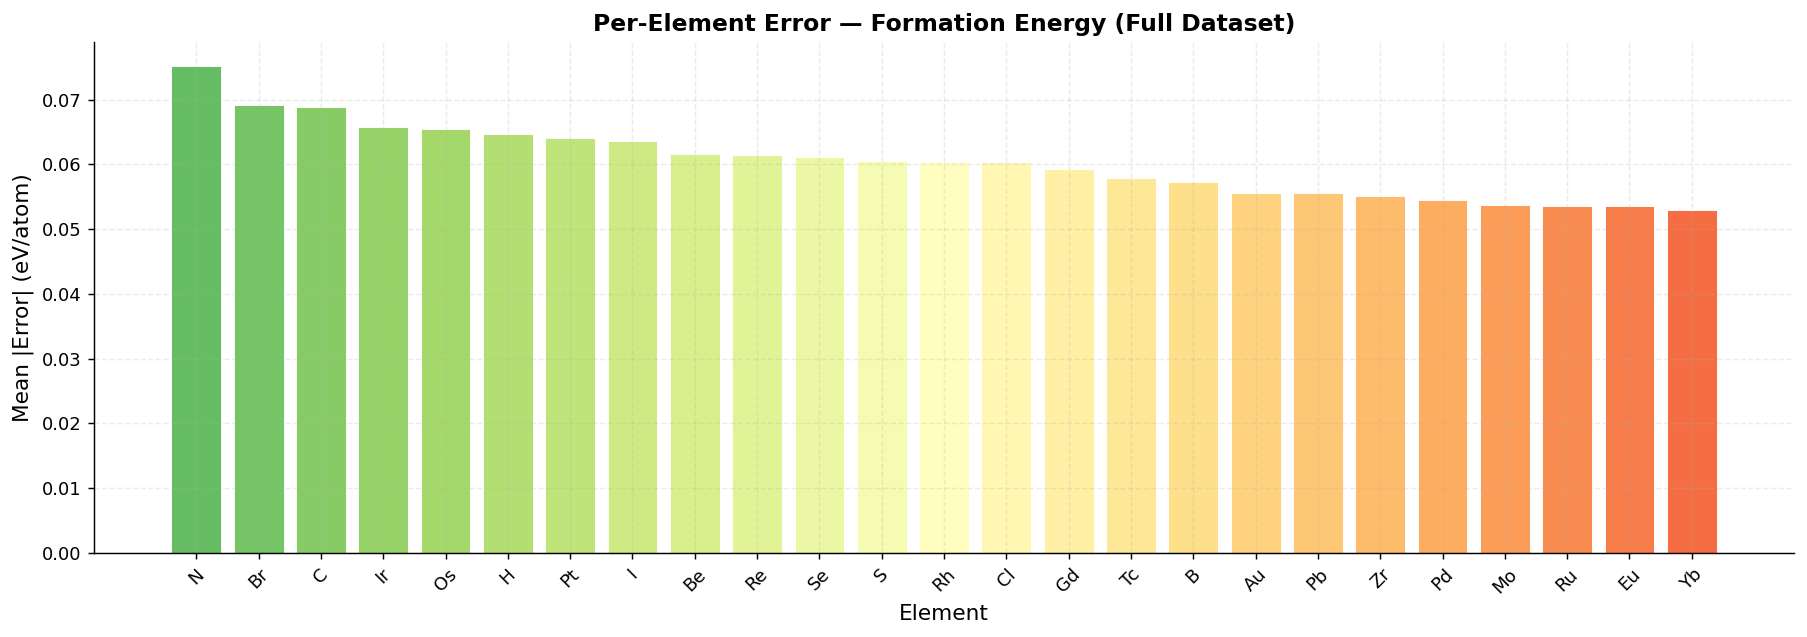

saved /kaggle/working/outputs/plot_12_per_element_error.png


In [23]:
def per_element_error(test_graphs, preds, trues):
    elem_errors = defaultdict(list)
    for i, g in enumerate(test_graphs):
        elems_in_struct = set()
        for j in range(g.x.shape[0]):
            eidx = g.x[j, :n_elem].argmax().item()
            if eidx < len(_elements):
                elems_in_struct.add(_elements[eidx])
        err = abs(preds[i] - trues[i])
        for el in elems_in_struct:
            elem_errors[el].append(err)
    return {el: np.mean(errs) for el, errs in elem_errors.items() if len(errs) >= 5}


elem_err = per_element_error(e_test, pred_eform_pt, true_eform_pt)
sorted_elems = sorted(elem_err.items(), key=lambda x: x[1], reverse=True)[:25]

fig, ax = plt.subplots(figsize=(14, 5))
elem_names = [e[0] for e in sorted_elems]
elem_vals = [e[1] for e in sorted_elems]
elem_colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(elem_names)))
ax.bar(elem_names, elem_vals, color=elem_colors, edgecolor='white', lw=0.5)
ax.set_xlabel("Element", fontsize=12)
ax.set_ylabel("Mean |Error| (eV/atom)", fontsize=12)
ax.set_title("Per-Element Error — Formation Energy (Full Dataset)",
             fontweight='bold', fontsize=13)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
path = os.path.join(cfg["out_dir"], "plot_12_per_element_error.png")
plt.savefig(path, dpi=130, bbox_inches='tight')
plt.show()
print(f"saved {path}")

MC dropout for e_form...
MC dropout for bandgap...


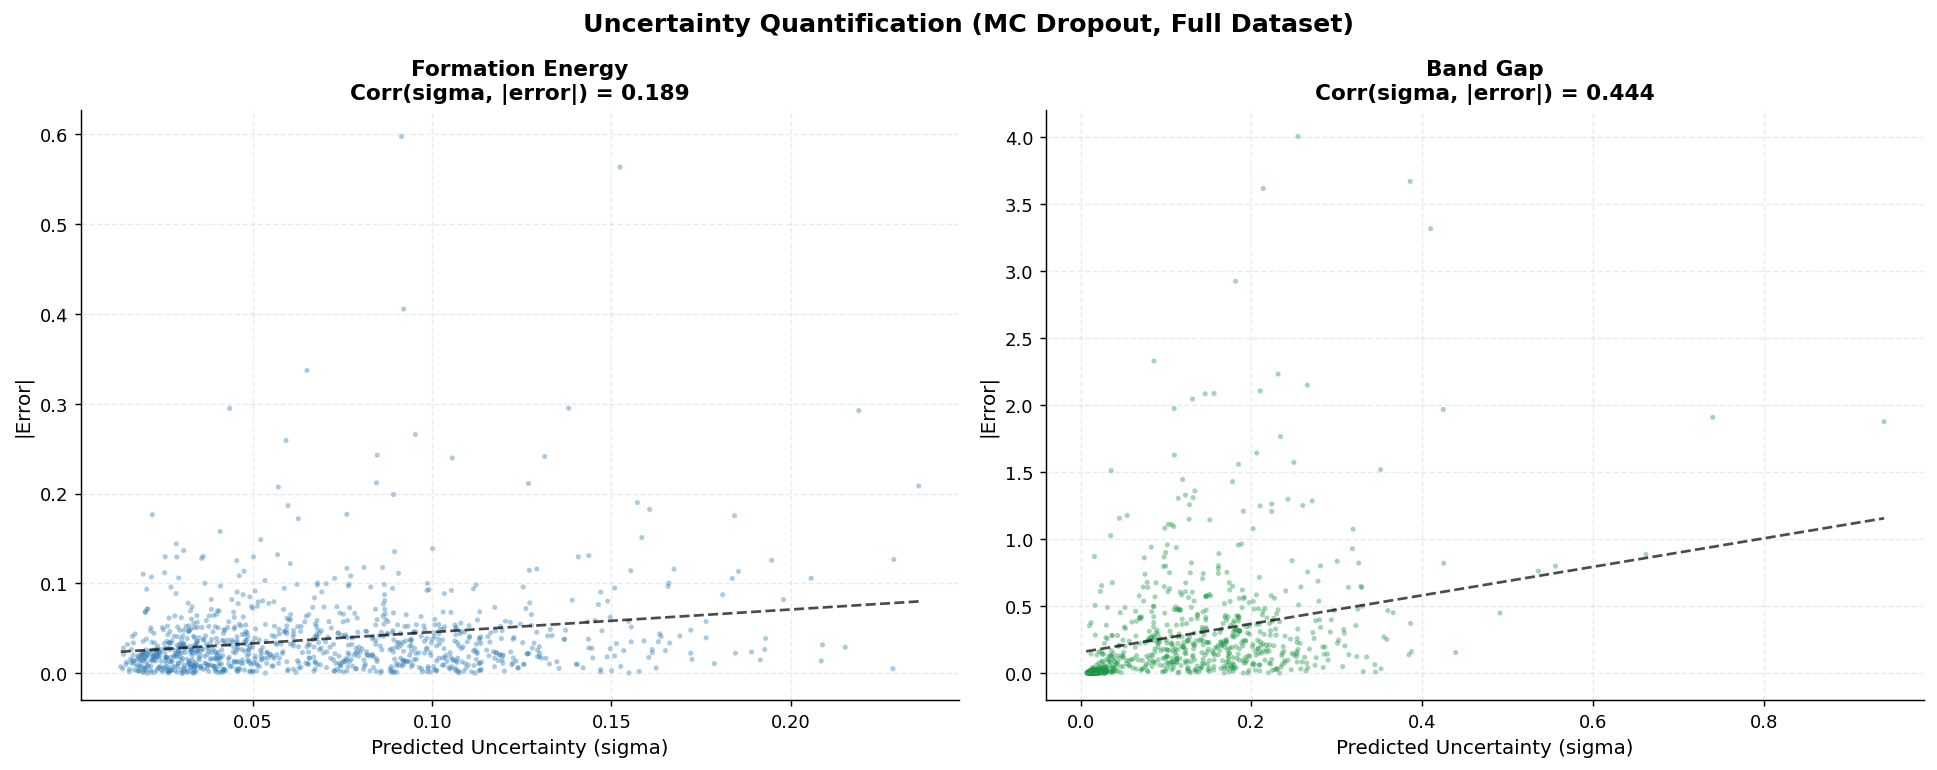

saved /kaggle/working/outputs/plot_13_uncertainty.png


In [24]:
def mc_dropout(model, test_graphs, device, n_forward=20):
    model.train() 
    loader = DataLoader(test_graphs, batch_size=64, shuffle=False)
    all_preds = []
    for _ in range(n_forward):
        preds = []
        with torch.no_grad():
            for batch in loader:
                batch = batch.to(device)
                with autocast(enabled=cfg["amp"]):
                    p = model(batch).squeeze(-1)
                preds.append(p.cpu().numpy())
        all_preds.append(np.concatenate(preds))
    model.eval()
    all_preds = np.array(all_preds)
    return all_preds.mean(axis=0), all_preds.std(axis=0)


print("MC dropout for e_form...")
mc_mean_e, mc_std_e = mc_dropout(model_eform_pt, e_test[:1000], cfg["device"])
true_e_sub = np.array([g.y.item() for g in e_test[:1000]])

print("MC dropout for bandgap...")
mc_mean_g, mc_std_g = mc_dropout(model_gap_pt, g_test[:1000], cfg["device"])
true_g_sub = np.array([g.y.item() for g in g_test[:1000]])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Uncertainty Quantification (MC Dropout, Full Dataset)",
             fontsize=14, fontweight='bold')

for ax, means, stds, trues, title, color in [
    (axes[0], mc_mean_e, mc_std_e, true_e_sub, "Formation Energy", COLORS[0]),
    (axes[1], mc_mean_g, mc_std_g, true_g_sub, "Band Gap", COLORS[2]),
]:
    errors = np.abs(means - trues)
    ax.scatter(stds, errors, s=8, alpha=0.4, color=color, edgecolors='none')

    z = np.polyfit(stds, errors, 1)
    poly = np.poly1d(z)
    x_line = np.linspace(stds.min(), stds.max(), 100)
    ax.plot(x_line, poly(x_line), '--', color='black', lw=1.5, alpha=0.7)

    corr = np.corrcoef(stds, errors)[0, 1]
    ax.set_xlabel("Predicted Uncertainty (sigma)", fontsize=11)
    ax.set_ylabel("|Error|", fontsize=11)
    ax.set_title(f"{title}\nCorr(sigma, |error|) = {corr:.3f}", fontweight='bold')

plt.tight_layout()
path = os.path.join(cfg["out_dir"], "plot_13_uncertainty.png")
plt.savefig(path, dpi=130, bbox_inches='tight')
plt.show()
print(f"saved {path}")

extracting layer representations...


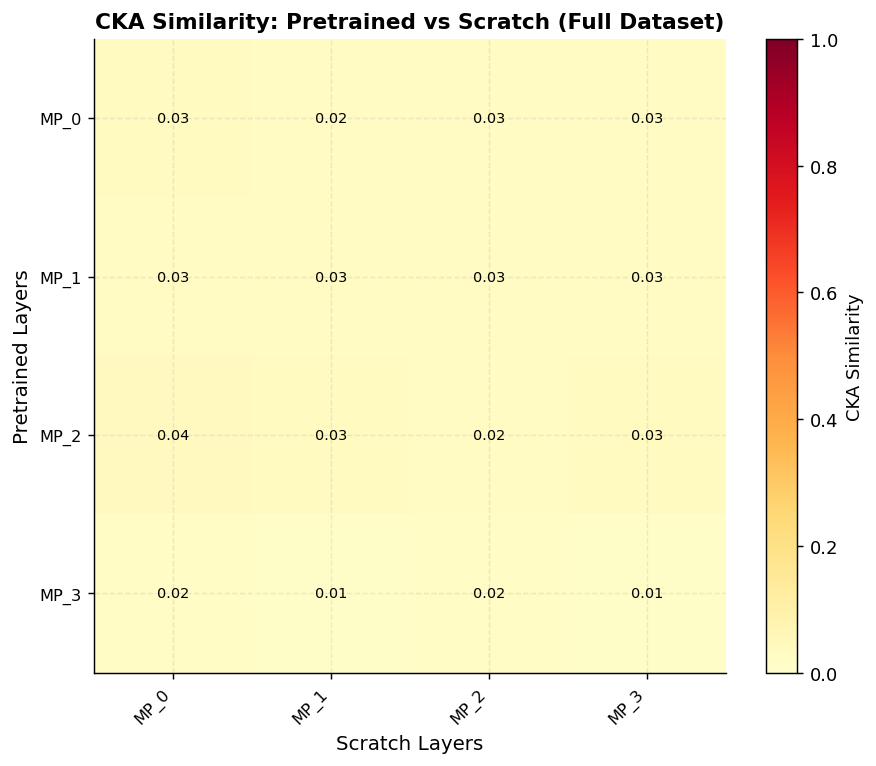

saved /kaggle/working/outputs/plot_14_cka.png


In [25]:
def extract_layer_reps(model, graphs, device, max_n=500):
    model.eval()
    loader = DataLoader(graphs[:max_n], batch_size=32, shuffle=False)
    layer_reps = defaultdict(list)

    def make_hook(name):
        def hook(module, inp, out):
            if isinstance(out, tuple):
                layer_reps[name].append(out[0].detach().cpu())
            else:
                layer_reps[name].append(out.detach().cpu())
        return hook

    hooks = []
    for i, mp in enumerate(model.encoder.mp):
        hooks.append(mp.register_forward_hook(make_hook(f"MP_{i}")))

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            model(batch)

    for h in hooks:
        h.remove()

    return {name: torch.cat(reps, dim=0).numpy() for name, reps in layer_reps.items()}


def linear_cka(X, Y):
    X = X - X.mean(0)
    Y = Y - Y.mean(0)
    hsic_xy = np.trace(X.T @ X @ Y.T @ Y) 
    hsic_xx = np.trace((X.T @ X) @ (X.T @ X))
    hsic_yy = np.trace((Y.T @ Y) @ (Y.T @ Y))
    return hsic_xy / (np.sqrt(hsic_xx * hsic_yy) + 1e-10)


print("extracting layer representations...")
reps_pt = extract_layer_reps(model_eform_pt, e_test, cfg["device"])
reps_sc = extract_layer_reps(model_eform_sc, e_test, cfg["device"])

layer_names = sorted(reps_pt.keys())
n_layers = len(layer_names)

cka_matrix = np.zeros((n_layers, n_layers))
for i, l1 in enumerate(layer_names):
    for j, l2 in enumerate(layer_names):
        r1 = reps_pt[l1][:500]
        r2 = reps_sc[l2][:500]
        min_n = min(r1.shape[0], r2.shape[0])
        cka_matrix[i, j] = linear_cka(r1[:min_n], r2[:min_n])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cka_matrix, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(n_layers))
ax.set_xticklabels(layer_names, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(n_layers))
ax.set_yticklabels(layer_names, fontsize=9)
ax.set_xlabel("Scratch Layers", fontsize=11)
ax.set_ylabel("Pretrained Layers", fontsize=11)
ax.set_title("CKA Similarity: Pretrained vs Scratch (Full Dataset)",
             fontweight='bold', fontsize=12)
plt.colorbar(im, ax=ax, label="CKA Similarity")
for i in range(n_layers):
    for j in range(n_layers):
        ax.text(j, i, f"{cka_matrix[i, j]:.2f}", ha='center', va='center',
                fontsize=8, color='white' if cka_matrix[i, j] > 0.5 else 'black')
plt.tight_layout()
path = os.path.join(cfg["out_dir"], "plot_14_cka.png")
plt.savefig(path, dpi=130, bbox_inches='tight')
plt.show()
print(f"saved {path}")

ABLATION STUDY
running MAR-only and contrastive-only pretraining variants

--- MAR-only pretraining ---
  [mar_only] epoch 5/10  loss=0.0479
  [mar_only] epoch 10/10  loss=0.0086
  finetuning MAR-only model...
  loaded pretrained encoder
  finetuning [ablation_mar_only] (pt)  train=92926 val=19913 test=19913
    ep     train       val      test   time
  ------------------------------------------
     1    1.0310    1.5386    1.5404    22s
  --- encoder unfrozen at epoch 4 ---
     5    0.1306    0.2251    0.2254    35s
    10    0.0931    0.0832    0.0835    35s
    15    0.0844    0.0579    0.0577    35s
  best model -> /kaggle/working/outputs/best_ablation_mar_only_pt.pt  (val MAE = 0.0579)
  *** final test MAE: 0.0577  R2: 0.9936 ***

--- contrastive-only pretraining ---
  [con_only] epoch 5/10  loss=0.0002
  [con_only] epoch 10/10  loss=0.0002
  finetuning contrastive-only model...
  loaded pretrained encoder
  finetuning [ablation_con_only] (pt)  train=92926 val=19913 test=19913
 

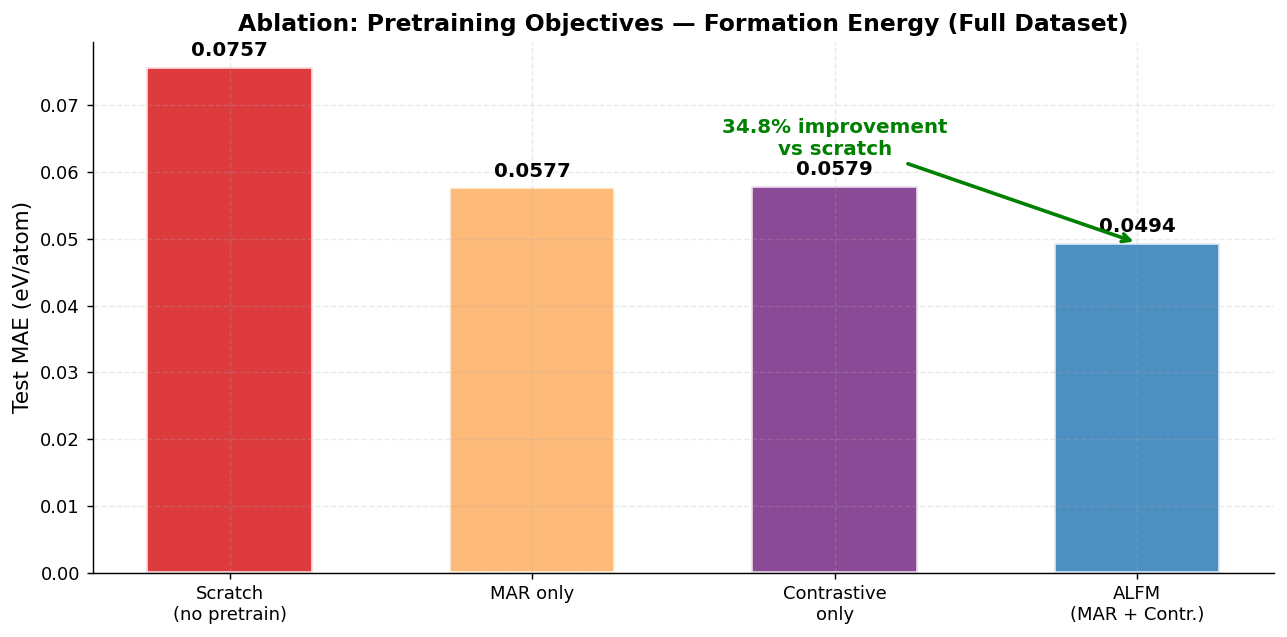

saved /kaggle/working/outputs/plot_15_ablation.png


In [26]:
print("=" * 55)
print("ABLATION STUDY")
print("running MAR-only and contrastive-only pretraining variants")
print("=" * 55)


def pretrain_ablation(model, graphs, c, variant="full"):
    loader = DataLoader(graphs, batch_size=c["pt_batch"], shuffle=True,
                        num_workers=0, pin_memory=True)
    opt = AdamW(model.parameters(), lr=c["pt_lr"], weight_decay=c["wd"])
    sched = CosineAnnealingLR(opt, T_max=10)  
    scaler = GradScaler(enabled=c["amp"])

    model.to(c["device"])
    model.train()

    for ep in range(1, 11):
        for batch in loader:
            batch = batch.to(c["device"])
            opt.zero_grad()

            with autocast(enabled=c["amp"]):
                if variant == "mar_only":
                    loss = masked_recon_loss(model, batch, c["mask_ratio"])
                elif variant == "con_only":
                    z1 = model.contrastive_proj(augment_graph(batch))
                    z2 = model.contrastive_proj(augment_graph(batch))
                    loss = nt_xent(z1, z2, c["temperature"])
                else:
                    l_mar = masked_recon_loss(model, batch, c["mask_ratio"])
                    z1 = model.contrastive_proj(augment_graph(batch))
                    z2 = model.contrastive_proj(augment_graph(batch))
                    l_con = nt_xent(z1, z2, c["temperature"])
                    loss = l_mar + c["con_weight"] * l_con

            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()

        sched.step()
        if ep % 5 == 0:
            print(f"  [{variant}] epoch {ep}/10  loss={loss.item():.4f}")

    return model


def ablation_finetune(pretrained_model, train_g, val_g, test_g, name, c):
    tmp_path = os.path.join(c["out_dir"], f"_ablation_{name}_enc.pt")
    torch.save(pretrained_model.encoder.state_dict(), tmp_path)

    m = ALFMNet().to(c["device"])
    m.encoder.load_state_dict(torch.load(tmp_path, map_location=c["device"]))

    quick_c = {**c, "ft_epochs": 15, "freeze_epochs": 3}
    _, mae, _, _ = finetune(m, train_g, val_g, test_g,
                            f"ablation_{name}", quick_c, pretrained=True)

    if os.path.exists(tmp_path):
        os.remove(tmp_path)

    return mae

ablation_cache = os.path.join(cfg["out_dir"], "ablation_results.json")
if os.path.exists(ablation_cache):
    print("loading cached ablation results...")
    with open(ablation_cache) as f:
        abl_results = json.load(f)
    mae_mar_only = abl_results["mar_only"]
    mae_con_only = abl_results["con_only"]
else:
    print("\n--- MAR-only pretraining ---")
    m_mar = ALFMNet().to(cfg["device"])
    pretrain_ablation(m_mar, all_pretrain, cfg, variant="mar_only")
    print("  finetuning MAR-only model...")
    mae_mar_only = ablation_finetune(m_mar, e_train, e_val, e_test, "mar_only", cfg)
    del m_mar
    torch.cuda.empty_cache()

    print("\n--- contrastive-only pretraining ---")
    m_con = ALFMNet().to(cfg["device"])
    pretrain_ablation(m_con, all_pretrain, cfg, variant="con_only")
    print("  finetuning contrastive-only model...")
    mae_con_only = ablation_finetune(m_con, e_train, e_val, e_test, "con_only", cfg)
    del m_con
    torch.cuda.empty_cache()

    with open(ablation_cache, 'w') as f:
        json.dump({"mar_only": mae_mar_only, "con_only": mae_con_only}, f)

ablation_labels = ["Scratch\n(no pretrain)", "MAR only", "Contrastive\nonly",
                   "ALFM\n(MAR + Contr.)"]
ablation_maes = [mae_eform_sc, mae_mar_only, mae_con_only, mae_eform_pt]
abl_colors = [COLORS[1], COLORS[3], COLORS[4], COLORS[0]]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(ablation_labels, ablation_maes, color=abl_colors, alpha=0.85,
              edgecolor='white', lw=2, width=0.55)
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.001,
            f"{b.get_height():.4f}", ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_ylabel("Test MAE (eV/atom)", fontsize=12)
ax.set_title("Ablation: Pretraining Objectives — Formation Energy (Full Dataset)",
             fontweight='bold', fontsize=13)

imp_full = (mae_eform_sc - mae_eform_pt) / mae_eform_sc * 100
ax.annotate(f"{imp_full:.1f}% improvement\nvs scratch",
            xy=(3, mae_eform_pt),
            xytext=(2.0, (mae_eform_sc + mae_eform_pt) / 2),
            arrowprops=dict(arrowstyle='->', color='green', lw=2),
            fontsize=11, color='green', fontweight='bold', ha='center')

plt.tight_layout()
path = os.path.join(cfg["out_dir"], "plot_15_ablation.png")
plt.savefig(path, dpi=130, bbox_inches='tight')
plt.show()
print(f"saved {path}")